# Temporal Fusion: Kernel Aggregation for Sparse News Data

Aligning irregular news events with dense market time series using exponential decay kernels.


In [1]:
import os

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
ts_path = Path.cwd() / "data" / "time_series"

text_path = Path.cwd() / "data" / "text"

images_path = Path.cwd() / "images"
images_path.mkdir(parents=True, exist_ok=True)

csv_files = sorted(ts_path.glob("*.csv"))

In [3]:
print(f"{len(csv_files)} Ticker(s) found in {ts_path}")

ticker_to_df = {}
n_tickers = 100

for i, csv_file in enumerate(csv_files):

    if i >= n_tickers:
        break

    df = pd.read_csv(csv_file)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
    df = df.dropna(subset=["Date"]).sort_values("Date")
    df["Date"] = df["Date"].dt.tz_convert("UTC").dt.tz_localize(None)
    ticker_to_df[csv_file.stem] = df

4213 Ticker(s) found in /home/rodrigodog/latent_fusion/data/time_series


## News Sparsity Challenge

Financial news data exhibits **critical sparsity patterns** that complicate direct alignment with time series:

### The Sparsity Problem

1. **Temporal Irregularity**: News arrives in bursts and gaps
   - Some stocks get 10+ articles per day
   - Others have days, weeks, or months with zero coverage
   - Creates jagged, non-uniform temporal distribution

2. **Mismatch with Market Data**: 
   - Market data: daily OHLCV (continuous, dense)
   - News data: event-driven (sparse, irregular)
   - Direct alignment impossible on non-news days

3. **Information Loss**:
   - Naive approach: only embeddings on news days
   - Result: **~70-90% of trading days have no context**
   - Market continues moving while data gaps exist


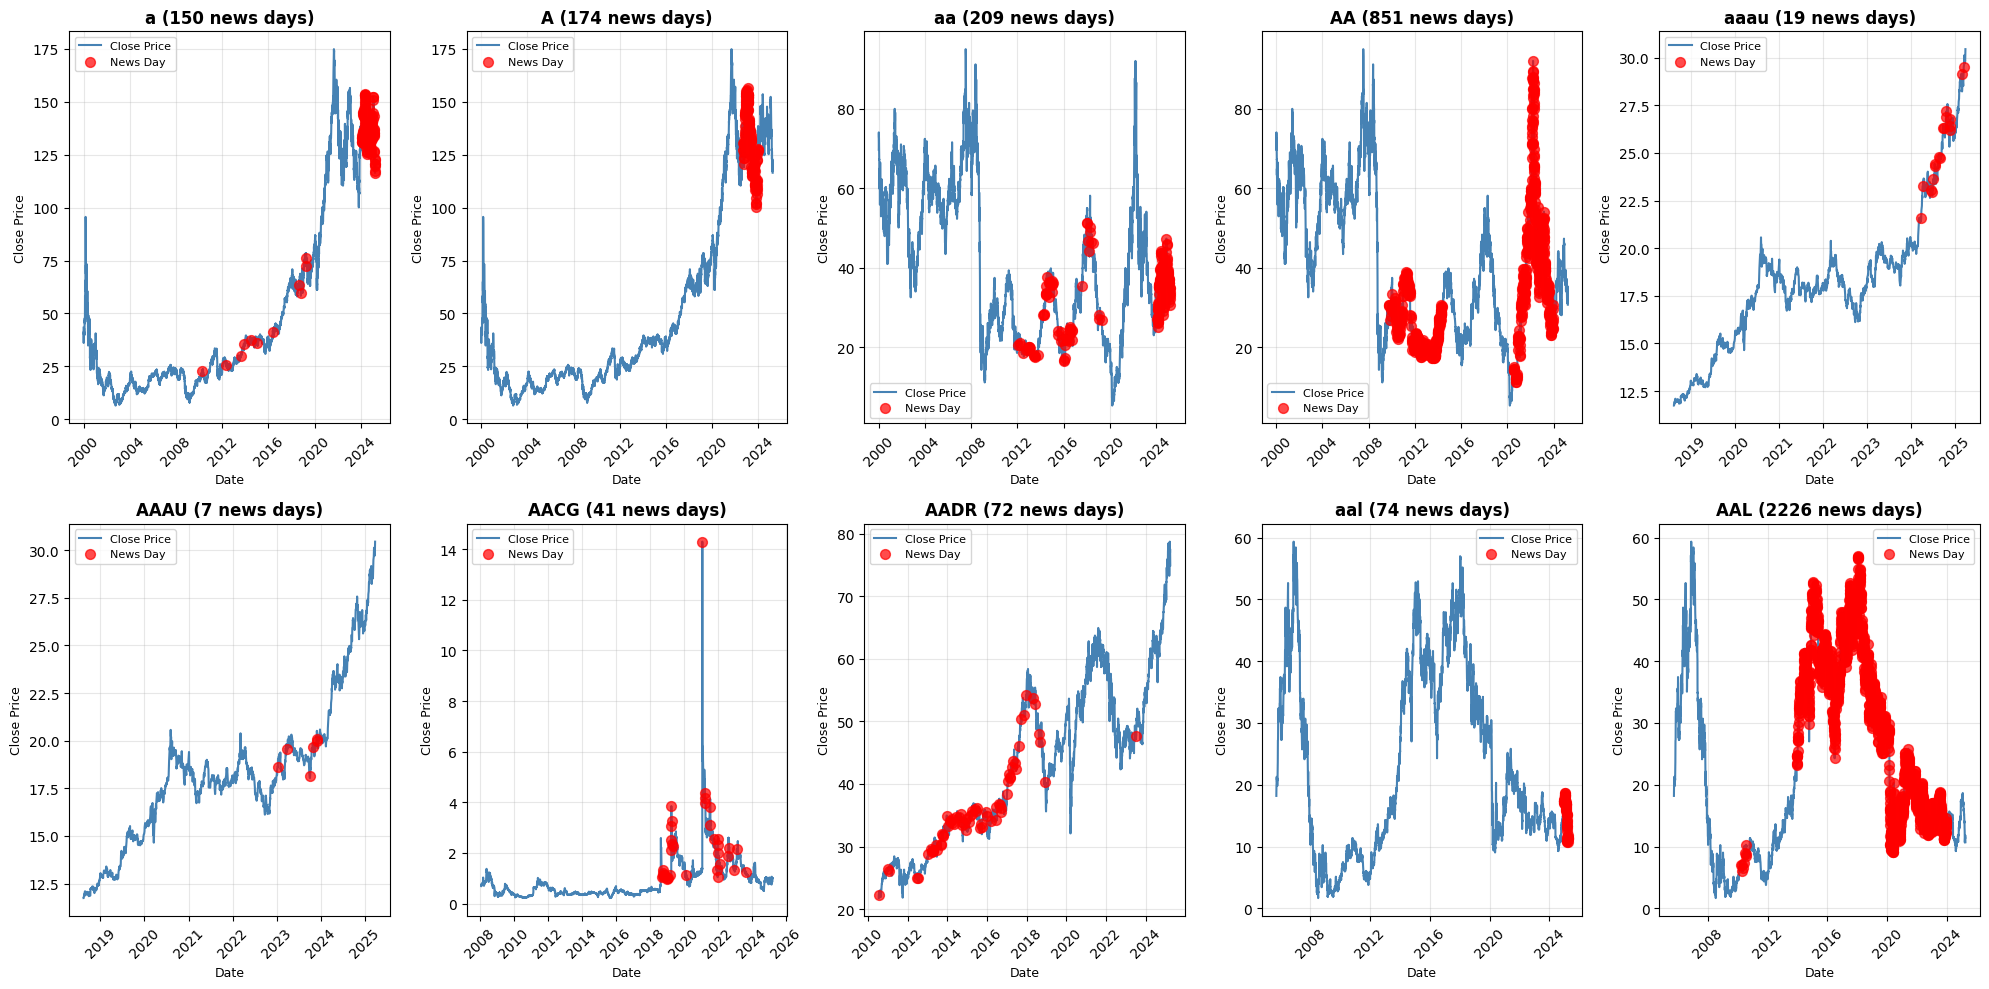

In [4]:
aligned_df = pd.read_csv('data/aligned_news_timeseries.csv')
aligned_df['news_date'] = pd.to_datetime(aligned_df['news_date'])
all_tickers = aligned_df['stock_symbol'].unique()
first_10_tickers = all_tickers[:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, ticker in enumerate(first_10_tickers):
    ax = axes[idx]
    
    # Get ticker data
    ticker_df = aligned_df[aligned_df['stock_symbol'] == ticker].copy()
    
    # Load time series data
    ts_file = Path('data/time_series') / f'{ticker.lower()}.csv'
    if ts_file.exists():
        ts_df = pd.read_csv(ts_file)
        ts_df['Date'] = pd.to_datetime(ts_df['Date'], utc=True).dt.tz_localize(None)
        ts_df = ts_df.sort_values('Date')
        
        news_dates = pd.to_datetime(ticker_df['news_date'], utc=True).dt.tz_localize(None).dt.date.unique()
        news_dates_set = set(news_dates)
        
        ax.plot(ts_df['Date'], ts_df['Close'], linewidth=1.5, color='steelblue', label='Close Price')
        
        # Mark dates with news as red dots
        ts_with_news = ts_df[ts_df['Date'].dt.date.isin(news_dates_set)]
        ax.scatter(ts_with_news['Date'], ts_with_news['Close'], color='red', s=50, zorder=5, label='News Day', alpha=0.7)
        
        # Formatting
        ax.set_title(f'{ticker} ({len(news_dates)} news days)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Close Price', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f'{ticker} data not found', ha='center', va='center')
        ax.set_title(f'{ticker}')

plt.tight_layout()
plt.show()

In [5]:
import json
import torch
from sentence_transformers import SentenceTransformer

ticker = list(ticker_to_df.keys())[0]
jsonl_path = text_path / f"{ticker.upper()}.jsonl"

articles = []
with open(jsonl_path) as f:
    for line in f:
        articles.append(json.loads(line))

print(f"Loaded {len(articles)} articles from {ticker}.jsonl")
print(f"Date range: {articles[0]['Date']} to {articles[-1]['Date']}")
print(f"Sample article length: {len(articles[0]['Article'])} chars")

text_alignment_df = pd.DataFrame([
    {
        "ticker": a["Stock_symbol"].upper(),
        "date": pd.to_datetime(a["Date"]),
        "text": a["Article"],
        "url": a["Url"]
    }
    for a in articles
])

text_alignment_df = text_alignment_df.dropna(subset=["text"])
print(f"\nText alignment DF shape: {text_alignment_df.shape}")

Loaded 642 articles from a.jsonl
Date range: 2025-04-15 to 2010-04-15
Sample article length: 1062 chars

Text alignment DF shape: (642, 4)


In [6]:
cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
cluster_df["ticker"] = cluster_df["ticker"].astype(str)
cluster_df["text"] = cluster_df["text"].fillna("").astype(str)
cluster_df = cluster_df[cluster_df["text"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Embedding {len(cluster_df)} articles...")

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embedding_dim = embedding_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {embedding_dim}")

batch_size = 32
x_text_list = []

for i in range(0, len(cluster_df), batch_size):
    batch_texts = cluster_df["text"].iloc[i:i+batch_size].tolist()
    batch_texts = [t[:4000] for t in batch_texts]  # truncate long texts
    embeddings = embedding_model.encode(batch_texts, show_progress_bar=False)
    x_text_list.append(embeddings)
    if (i + batch_size) % 128 == 0:
        print(f"  [{i}/{len(cluster_df)}]")

x_text = np.vstack(x_text_list)
cluster_df["text_embedding"] = list(x_text)
print(f"✓ Embeddings shape: {x_text.shape}")

Embedding 642 articles...


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has be

Embedding dimension: 384
  [96/642]
  [224/642]
  [352/642]
  [480/642]
  [608/642]
✓ Embeddings shape: (642, 384)


### Why conditioning is needed

Raw news text mixes signal and noise. A conditioning step imposes a consistent analytical lens so each document is interpreted through the same conceptual dimensions (firm impact, risk profile, catalysts, and outlook). This reduces semantic variance caused by language form and increases variance explained by economic content.

### Representation learning perspective

In embedding terms, conditioning acts like a task-aligned projection before vectorization. Instead of mapping heterogeneous text directly into a latent space, the process first normalizes the semantic structure, then embeds. This tends to improve comparability across firms, dates, and regimes.


### Robustness and continuity

Financial news is sparse and irregular in time. A stable representation pipeline is therefore essential: if two runs produce inconsistent latent points for equivalent information, temporal aggregation becomes noisy. Persisting intermediate semantic outputs enforces continuity across runs and supports reproducible longitudinal analysis.

In [7]:
# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import torch
# from openai import OpenAI
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# api_key = os.getenv("OPENAI_API_KEY")
# if not api_key:
#     raise ValueError("OPENAI_API_KEY is not set")

# client = OpenAI(api_key=api_key)

# if "text_alignment_df" not in globals() or text_alignment_df is None:
#     if "cluster_df" in globals() and isinstance(cluster_df, pd.DataFrame):
#         req = {"ticker", "date", "text"}
#         if req.issubset(set(cluster_df.columns)):
#             text_alignment_df = cluster_df[["ticker", "date", "text"]].copy()
#         else:
#             raise ValueError("cluster_df exists but does not contain ticker/date/text columns")
#     elif "articles" in globals() and isinstance(articles, list) and len(articles) > 0:
#         text_alignment_df = pd.DataFrame([
#             {
#                 "ticker": a.get("Stock_symbol", "").upper(),
#                 "date": pd.to_datetime(a.get("Date"), errors="coerce"),
#                 "text": a.get("Article", "")
#             }
#             for a in articles
#         ]).dropna(subset=["date"])
#     else:
#         raise NameError("text_alignment_df is missing. Run Cell 7 first, or define cluster_df with ticker/date/text.")

# llm_cluster_df = text_alignment_df[["ticker", "date", "text"]].copy()
# llm_cluster_df["ticker"] = llm_cluster_df["ticker"].astype(str).str.upper()
# llm_cluster_df["text"] = llm_cluster_df["text"].fillna("").astype(str)
# llm_cluster_df = llm_cluster_df[llm_cluster_df["text"].str.strip().str.len() > 0].reset_index(drop=True)

# analysis_model = "gpt-4o-mini"
# embedding_model = "text-embedding-3-small"
# embedding_dim = 512

# cache_dir = Path("cache") / "text"
# cache_dir.mkdir(parents=True, exist_ok=True)
# cache_text_file = cache_dir / "gpt_conditioned_text.parquet"
# cache_emb_file = cache_dir / "gpt_conditioned_embeddings.npy"

# def build_firm_prompt(ticker, date_str, raw_text):
#     return f"""You are a professional equity research analyzer for an institutional investment firm.
# Write a firm-specific analyst memo for {ticker.upper()} based on the news below.
# Date: {date_str}
# News:
# {raw_text if raw_text.strip() else 'No concrete article text was provided for this date.'}

# Return exactly 10 concise bullet points focused on {ticker.upper()}:
# - what this means for this specific firm
# - business segment impact
# - near-term catalysts
# - medium-term risks
# - earnings and margin implications
# - balance sheet or liquidity implications
# - competitive positioning
# - regulatory or macro sensitivity
# - sentiment direction with confidence
# - 1-3 month investment takeaway
# """

# llm_cluster_df["prompt_text"] = llm_cluster_df.apply(
#     lambda r: build_firm_prompt(
#         ticker=r["ticker"],
#         date_str=pd.to_datetime(r["date"]).strftime("%Y-%m-%d"),
#         raw_text=r["text"][:12000],
#     ),
#     axis=1,
# )
# llm_cluster_df["cache_key"] = (
#     llm_cluster_df["ticker"].astype(str) + "|" +
#     pd.to_datetime(llm_cluster_df["date"]).dt.strftime("%Y-%m-%d") + "|" +
#     llm_cluster_df["text"].astype(str).str.slice(0, 1000)
# ).map(lambda s: str(abs(hash(s))))

# cached_text_df = None
# if cache_text_file.exists():
#     try:
#         cached_text_df = pd.read_parquet(cache_text_file)
#         needed_cols = {"cache_key", "gpt_text"}
#         if not needed_cols.issubset(set(cached_text_df.columns)):
#             cached_text_df = None
#     except Exception:
#         cached_text_df = None

# def summarize_with_gpt(prompt_text):
#     response = client.responses.create(
#         model=analysis_model,
#         input=prompt_text,
#         max_output_tokens=500,
#     )
#     return response.output_text.strip()

# if cached_text_df is not None:
#     key_to_text = dict(zip(cached_text_df["cache_key"].astype(str), cached_text_df["gpt_text"].astype(str)))
# else:
#     key_to_text = {}

# def flush_text_cache(existing_df, pending_rows):
#     if existing_df is None:
#         base_df = llm_cluster_df[["cache_key", "ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
#     else:
#         if pending_rows:
#             base_df = pd.concat([
#                 existing_df,
#                 pd.DataFrame(pending_rows)
#             ], ignore_index=True).drop_duplicates(subset=["cache_key"], keep="last")
#         else:
#             base_df = existing_df
#     base_df.to_parquet(cache_text_file, index=False)
#     return base_df

# print(f"Generating GPT-conditioned text for {len(llm_cluster_df)} samples...")
# gpt_texts = []
# new_rows = []
# checkpoint_every = 20

# try:
#     for i, row in llm_cluster_df.iterrows():
#         key = str(row["cache_key"])
#         if key in key_to_text and key_to_text[key].strip():
#             transformed = key_to_text[key]
#         else:
#             transformed = summarize_with_gpt(row["prompt_text"])
#             if not transformed:
#                 transformed = row["prompt_text"]
#             key_to_text[key] = transformed
#             new_rows.append({"cache_key": key, "gpt_text": transformed})
#         gpt_texts.append(transformed)
#         if (i + 1) % checkpoint_every == 0 and len(new_rows) > 0:
#             temp_df = llm_cluster_df.iloc[: i + 1].copy()
#             temp_df["gpt_text"] = gpt_texts
#             existing = cached_text_df if cached_text_df is not None else temp_df[["cache_key", "ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
#             cached_text_df = flush_text_cache(existing, new_rows)
#             new_rows = []
#         if (i + 1) % 64 == 0 or (i + 1) == len(llm_cluster_df):
#             print(f"  GPT pass [{i + 1}/{len(llm_cluster_df)}]")
# except KeyboardInterrupt:
#     print("\nInterrupted. Saving partial GPT cache...")
#     raise
# finally:
#     if len(gpt_texts) > 0:
#         llm_cluster_df.loc[: len(gpt_texts) - 1, "gpt_text"] = gpt_texts
#     if len(new_rows) > 0 or cached_text_df is None:
#         if "gpt_text" in llm_cluster_df.columns:
#             cached_text_df = flush_text_cache(cached_text_df, new_rows)
#         new_rows = []

# if "gpt_text" not in llm_cluster_df.columns:
#     llm_cluster_df["gpt_text"] = llm_cluster_df["cache_key"].map(key_to_text).fillna(llm_cluster_df["prompt_text"])
# else:
#     llm_cluster_df["gpt_text"] = llm_cluster_df["gpt_text"].fillna(llm_cluster_df["cache_key"].map(key_to_text)).fillna(llm_cluster_df["prompt_text"])

# print(f"Embedding {len(llm_cluster_df)} GPT-conditioned samples...")
# batch_size = 32
# prompt_embeddings = []

# for i in range(0, len(llm_cluster_df), batch_size):
#     batch_inputs = llm_cluster_df["gpt_text"].iloc[i:i + batch_size].tolist()
#     response = client.embeddings.create(
#         model=embedding_model,
#         input=batch_inputs,
#         dimensions=embedding_dim,
#     )
#     batch_vectors = [np.array(item.embedding, dtype=np.float32) for item in response.data]
#     prompt_embeddings.extend(batch_vectors)
#     if len(prompt_embeddings) > 0:
#         np.save(cache_emb_file, np.vstack(prompt_embeddings))
#     if (i + batch_size) % 128 == 0 or (i + batch_size) >= len(llm_cluster_df):
#         print(f"  Embed pass [{min(i + batch_size, len(llm_cluster_df))}/{len(llm_cluster_df)}]")

# x_text = np.vstack(prompt_embeddings)
# np.save(cache_emb_file, x_text)

# cluster_df = llm_cluster_df[["ticker", "date", "text", "prompt_text", "gpt_text"]].copy()
# cluster_df["text_embedding"] = list(x_text)
# print(f"✓ GPT-conditioned embeddings shape: {x_text.shape}")
# print(f"✓ Cached text: {cache_text_file}")
# print(f"✓ Cached embeddings: {cache_emb_file}")

## Kernel Aggregation: Handling News Sparsity

### The Problem: Event Sparsity

Financial news is **sparse and irregular**:
- Some days have 10+ articles, others have none
- Direct embedding matching breaks on non-news days
- Time series has DAILY samples, news has EVENT samples
- Can't simply align: (6172 events) ≠ (4495 days)

### The Solution: Kernel Aggregation

**Formula**: Project sparse events onto dense time axis using exponential decay kernel

$$z_{\text{text}}(t) = \sum_{i=1}^{E} \exp(-\lambda \cdot (t - t_i)) \cdot z_{\text{event}_i} \cdot \mathbb{1}_{t \geq t_i}$$

Where:
- $z_{\text{event}_i}$ = embedding of $i$-th news article
- $t_i$ = time of $i$-th article
- $\lambda$ = decay rate (controls "memory half-life")
- $\mathbb{1}_{t \geq t_i}$ = mask future events (no lookahead)

### Why This Works

1. **Closure**: Maps E events → T time steps (all days have context)
2. **Causality**: Only uses past news (exponential mask)
3. **Smoothness**: Recent news weighted more heavily
4. **Interpretability**: λ controls temporal weight distribution

### Decay Interpretation

| λ | Meaning | Half-life |
|---|---------|-----------|
| **0.01** | Long memory | 69 days (quarterly themes) |
| **0.05** | Medium memory | 14 days (monthly signals) |
| **0.1** | Short memory | 7 days (weekly noise) |

In [8]:
def build_text_context(z_events, event_times, time_steps, lambda_=0.1):
    """
    Kernel aggregation: projects events onto time axis
    
    Args:
        z_events: [E, D] event embeddings
        event_times: [E] event timestamps (as float timestamps)
        time_steps: [T] target time steps
        lambda_: decay parameter
    
    Returns:
        z_text_context: [T, D] aggregated text context at each time step
    """
    z_events = torch.FloatTensor(z_events)
    event_times = torch.FloatTensor(event_times)
    time_steps = torch.FloatTensor(time_steps)
    
    delta_t = time_steps.unsqueeze(1) - event_times.unsqueeze(0)  # [T, E]
    
    mask = delta_t < 0  # mask future events
    delta_t = torch.clamp(delta_t, min=0)
    
    weights = torch.exp(-lambda_ * delta_t)  # exponential decay
    weights[mask] = 0
    
    weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)  # normalize
    
    z_text_context = weights @ z_events  # [T, D]
    
    return z_text_context.numpy()

# Prepare data for kernel aggregation
cluster_df["date_float"] = cluster_df["date"].astype(np.int64) / 1e9
z_events = x_text  # [E, D]
event_times = cluster_df["date_float"].values  # [E]

# Create time_steps: every trading day in the date range
date_min = cluster_df["date"].min()
date_max = cluster_df["date"].max()
time_steps_range = pd.date_range(date_min, date_max, freq='D')
time_steps = (time_steps_range.astype(np.int64) / 1e9).values

print(f"Events: {len(event_times)}, Date range: {date_min.date()} to {date_max.date()}")
print(f"Time steps: {len(time_steps)} days")

# Apply kernel aggregation with multiple lambda values
lambdas = [0.01, 0.05, 0.1]
z_context_dict = {}

for lam in lambdas:
    z_context = build_text_context(z_events, event_times, time_steps, lambda_=lam)
    z_context_dict[lam] = z_context
    print(f"✓ Lambda={lam}: context shape {z_context.shape}")

Events: 642, Date range: 2010-04-15 to 2025-04-15
Time steps: 5480 days
✓ Lambda=0.01: context shape (5480, 384)
✓ Lambda=0.05: context shape (5480, 384)
✓ Lambda=0.1: context shape (5480, 384)


## Realized Volatility Analysis

Realized volatility measures the actual price fluctuations observed in the market over a specific period.

### Calculation Methods

1. **Parkinson Volatility** (High-Low range):
$$\sigma_{\text{Parkinson}} = \sqrt{\frac{1}{N} \sum \left(\ln\frac{H_i}{L_i}\right)^2 / (4\ln 2)} \times \sqrt{252}$$

2. **Close-to-Close Volatility** (Historical):
$$\sigma_{\text{Historical}} = \sqrt{\text{Var}(\text{returns})} \times \sqrt{252}$$

3. **Garman-Klass Volatility** (combines OHLC):
$$\sigma_{\text{GK}} = \sqrt{\frac{1}{N}\sum \left[0.5(\ln H_i/L_i)^2 - (2\ln 2 - 1)(\ln C_i/O_i)^2\right]} \times \sqrt{252}$$


This cell aligns kernel days with market data, computes three realized volatilities (Historical, Parkinson, and Garman-Klass), and creates `combined_vol` as their average.

It then attaches `combined_vol` to the daily aligned dataframe so the next PCA plot can color kernel days by this combined volatility signal.

Time series: 6348 records, 2000-01-03 05:00:00 to 2025-03-28 04:00:00
Volatility range: 0.0822 to 2.0341
✓ Merged DF: 3763 rows with valid volatility
Date range: 2010-04-15 00:00:00 to 2025-03-28 00:00:00
Volatility stats:
count    3763.000000
mean        0.263238
std         0.116479
min         0.082242
25%         0.189664
50%         0.241029
75%         0.303240
max         0.950589
Name: vol_20d, dtype: float64
Clean data points: 6328

Volatility Summary (annualized):
  Historical Vol: 0.3397 ± 0.2234
  Parkinson Vol:  0.2863 ± 0.1680
  Garman-Klass:   0.2847 ± 0.1619
  Combined Vol:   0.3036 ± 0.1813


/tmp/ipykernel_16600/1313680700.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vol_ts_clean['combined_vol'] = vol_ts_clean[['historical_vol', 'parkinson_vol', 'garman_klass_vol']].mean(axis=1)



✓ Saved to images/realized_volatility_analysis.png


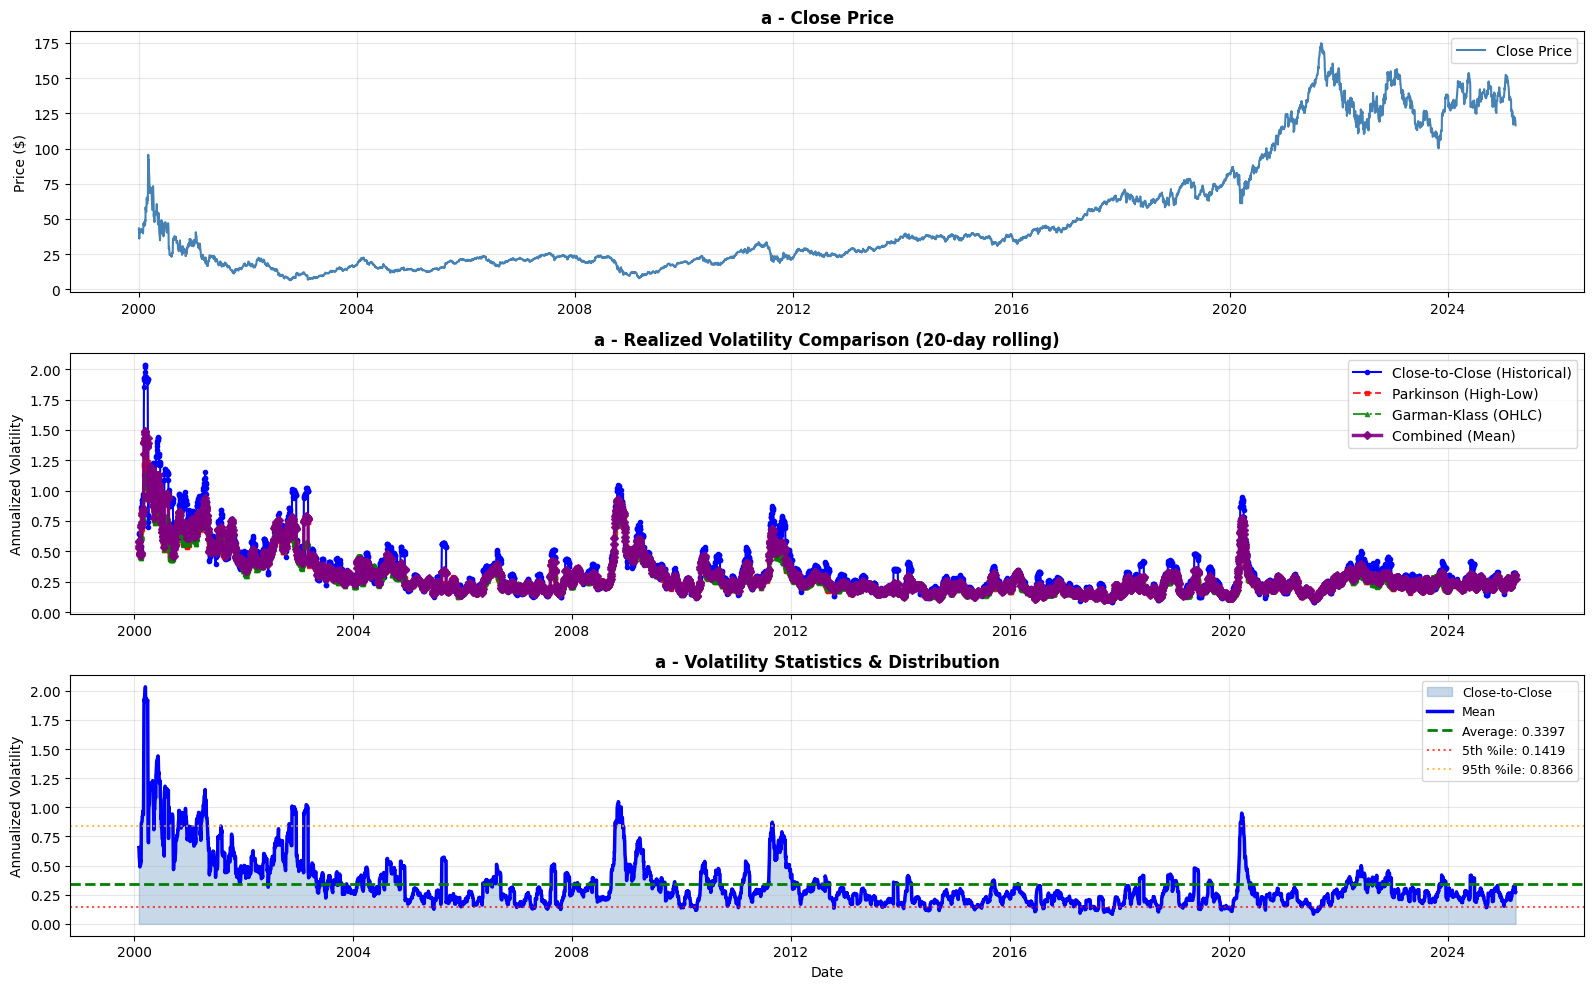

In [9]:
# Prepare kernel aggregation context and calculate realized volatility metrics
ticker_for_vol = list(ticker_to_df.keys())[0]
ts = ticker_to_df[ticker_for_vol].copy().sort_values('Date')

ts['returns'] = ts['Close'].pct_change()
ts['vol_20d'] = ts['returns'].rolling(20).std() * np.sqrt(252)  # annualized

print(f"Time series: {len(ts)} records, {ts['Date'].min()} to {ts['Date'].max()}")
print(f"Volatility range: {ts['vol_20d'].min():.4f} to {ts['vol_20d'].max():.4f}")

# Normalize dates (remove time component)
ts['Date_norm'] = ts['Date'].dt.normalize()

# Create alignment dataframe with scalar features only
alignment_df = pd.DataFrame({'date': time_steps_range})
alignment_df['date_norm'] = pd.to_datetime(alignment_df['date']).dt.normalize()

# Add z_context as lists of embeddings
alignment_df['z_context_01'] = [z_context_dict[0.01][i] for i in range(len(time_steps_range))]
alignment_df['z_context_05'] = [z_context_dict[0.05][i] for i in range(len(time_steps_range))]
alignment_df['z_context_10'] = [z_context_dict[0.1][i] for i in range(len(time_steps_range))]

# Merge on normalized date
merged_df = alignment_df.merge(
    ts[['Date_norm', 'Close', 'vol_20d']],
    left_on='date_norm',
    right_on='Date_norm',
    how='inner'
)

# Keep rows with valid volatility
merged_df = merged_df.dropna(subset=['vol_20d']).copy()

print(f"✓ Merged DF: {len(merged_df)} rows with valid volatility")
if len(merged_df) > 0:
    print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
    print(f"Volatility stats:\n{merged_df['vol_20d'].describe()}")

# Calculate realized volatility metrics
vol_ts = ts.copy()
rolling_window = 20

vol_ts['historical_vol'] = vol_ts['returns'].rolling(rolling_window).std() * np.sqrt(252)

if 'High' in vol_ts.columns and 'Low' in vol_ts.columns:
    vol_ts['hl_ratio'] = np.log(vol_ts['High'] / vol_ts['Low'])
    vol_ts['parkinson_vol'] = (vol_ts['hl_ratio'].rolling(rolling_window).apply(
        lambda x: np.sqrt(np.sum(x**2) / len(x) / (4 * np.log(2)))
    )) * np.sqrt(252)
    
    if 'Open' in vol_ts.columns:
        vol_ts['oc_ratio'] = np.log(vol_ts['Close'] / vol_ts['Open'])
        
        gk_values = []
        for i in range(len(vol_ts)):
            if i < rolling_window - 1:
                gk_values.append(np.nan)
            else:
                window_data = vol_ts.iloc[i-rolling_window+1:i+1]
                hl_log = np.log(window_data['High'] / window_data['Low'])
                co_log = np.log(window_data['Close'] / window_data['Open'])
                gk = np.sqrt(
                    0.5 * np.sum(hl_log**2) / rolling_window - 
                    (2 * np.log(2) - 1) * np.sum(co_log**2) / rolling_window
                ) * np.sqrt(252)
                gk_values.append(gk)
        vol_ts['garman_klass_vol'] = gk_values

vol_ts_clean = vol_ts.dropna(subset=['historical_vol'])
print(f"Clean data points: {len(vol_ts_clean)}")
print(f"\nVolatility Summary (annualized):")
print(f"  Historical Vol: {vol_ts_clean['historical_vol'].mean():.4f} ± {vol_ts_clean['historical_vol'].std():.4f}")
if 'parkinson_vol' in vol_ts_clean.columns:
    print(f"  Parkinson Vol:  {vol_ts_clean['parkinson_vol'].mean():.4f} ± {vol_ts_clean['parkinson_vol'].std():.4f}")
if 'garman_klass_vol' in vol_ts_clean.columns:
    print(f"  Garman-Klass:   {vol_ts_clean['garman_klass_vol'].mean():.4f} ± {vol_ts_clean['garman_klass_vol'].std():.4f}")

# Combined volatility: mean of all three methods
vol_ts_clean['combined_vol'] = vol_ts_clean[['historical_vol', 'parkinson_vol', 'garman_klass_vol']].mean(axis=1)
vol_ts_clean = vol_ts_clean.dropna(subset=['combined_vol'])
print(f"  Combined Vol:   {vol_ts_clean['combined_vol'].mean():.4f} ± {vol_ts_clean['combined_vol'].std():.4f}")

# Add combined volatility to merged_df
vol_for_merge = vol_ts_clean[['Date_norm', 'combined_vol']].drop_duplicates(subset=['Date_norm']).rename(columns={'combined_vol': 'combined_vol'})
merged_df = merged_df.merge(vol_for_merge, left_on='date_norm', right_on='Date_norm', how='left')

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(vol_ts['Date'], vol_ts['Close'], 'steelblue', linewidth=1.5, label='Close Price')
ax.set_title(f'{ticker_for_vol} - Close Price', fontweight='bold', fontsize=12)
ax.set_ylabel('Price ($)')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], 'b-', linewidth=1.5, label='Close-to-Close (Historical)', marker='o', markersize=3)
if 'parkinson_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['parkinson_vol'], 'r--', linewidth=1.5, label='Parkinson (High-Low)', alpha=0.8, marker='s', markersize=3)
if 'garman_klass_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['garman_klass_vol'], 'g-.', linewidth=1.5, label='Garman-Klass (OHLC)', alpha=0.8, marker='^', markersize=3)
if 'combined_vol' in vol_ts_clean.columns:
    ax.plot(vol_ts_clean['Date'], vol_ts_clean['combined_vol'], 'purple', linewidth=2.5, label='Combined (Mean)', marker='D', markersize=4, alpha=0.9)
ax.set_title(f'{ticker_for_vol} - Realized Volatility Comparison (20-day rolling)', fontweight='bold', fontsize=12)
ax.set_ylabel('Annualized Volatility')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[2]
vol_range = vol_ts_clean['historical_vol'].quantile([0.05, 0.95])
ax.fill_between(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], alpha=0.3, color='steelblue', label='Close-to-Close')
ax.plot(vol_ts_clean['Date'], vol_ts_clean['historical_vol'], 'b-', linewidth=2.5, label='Mean')
ax.axhline(vol_ts_clean['historical_vol'].mean(), color='green', linestyle='--', linewidth=2, label=f"Average: {vol_ts_clean['historical_vol'].mean():.4f}")
ax.axhline(vol_range.iloc[0], color='red', linestyle=':', linewidth=1.5, alpha=0.7, label=f"5th %ile: {vol_range.iloc[0]:.4f}")
ax.axhline(vol_range.iloc[1], color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f"95th %ile: {vol_range.iloc[1]:.4f}")
ax.set_title(f'{ticker_for_vol} - Volatility Statistics & Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/realized_volatility_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved to images/realized_volatility_analysis.png")
plt.show()


## Kernel Days PCA Colored by Combined Volatility

This plot projects the **kernel-aggregated context** into 2D (PCA) for each decay value $\lambda \in \{0.01, 0.05, 0.1\}$.

### PCA (what it means here)

- PCA is a linear dimensionality-reduction method that transforms high-dimensional kernel embeddings into orthogonal components.
- **PC1** is the direction of maximum variance in the kernel context; **PC2** is the second-most, orthogonal to PC1.
- Points that are close in the PCA plane have similar kernel-context representations.
- The percentages in the title (PCA1, PCA2) show how much total variance each axis explains.

### What is plotted

- **All kernel days are included** (full `time_steps_range`), not only market-overlap days.
- Each point is one day of kernel context after aggregation.
- PCA is fit on kernel context for each $\lambda$ and then plotted on PC1 vs PC2.

### Volatility color mapping

Color is based on **combined volatility**:

$$
\text{combined\_vol}_t = \frac{\sigma_{\text{historical},t} + \sigma_{\text{parkinson},t} + \sigma_{\text{gk},t}}{3}
$$

- Colored points: kernel days where `combined_vol` is available.
- Gray points: kernel days without `combined_vol` (typically due to rolling-window warmup or missing OHLC inputs).
- Color values are clipped to the 5th-95th percentile range for readability.

### Why this view is useful

- Keeps the full temporal kernel representation visible.
- Highlights where market volatility information exists.
- Lets you compare how different decay memories ($\lambda$) reshape the kernel-context geometry.

✓ Saved to images/kernel_days_combined_vol_colormap.png
  Kernel context days shown (all): 5480
  Kernel days with combined volatility: 3763


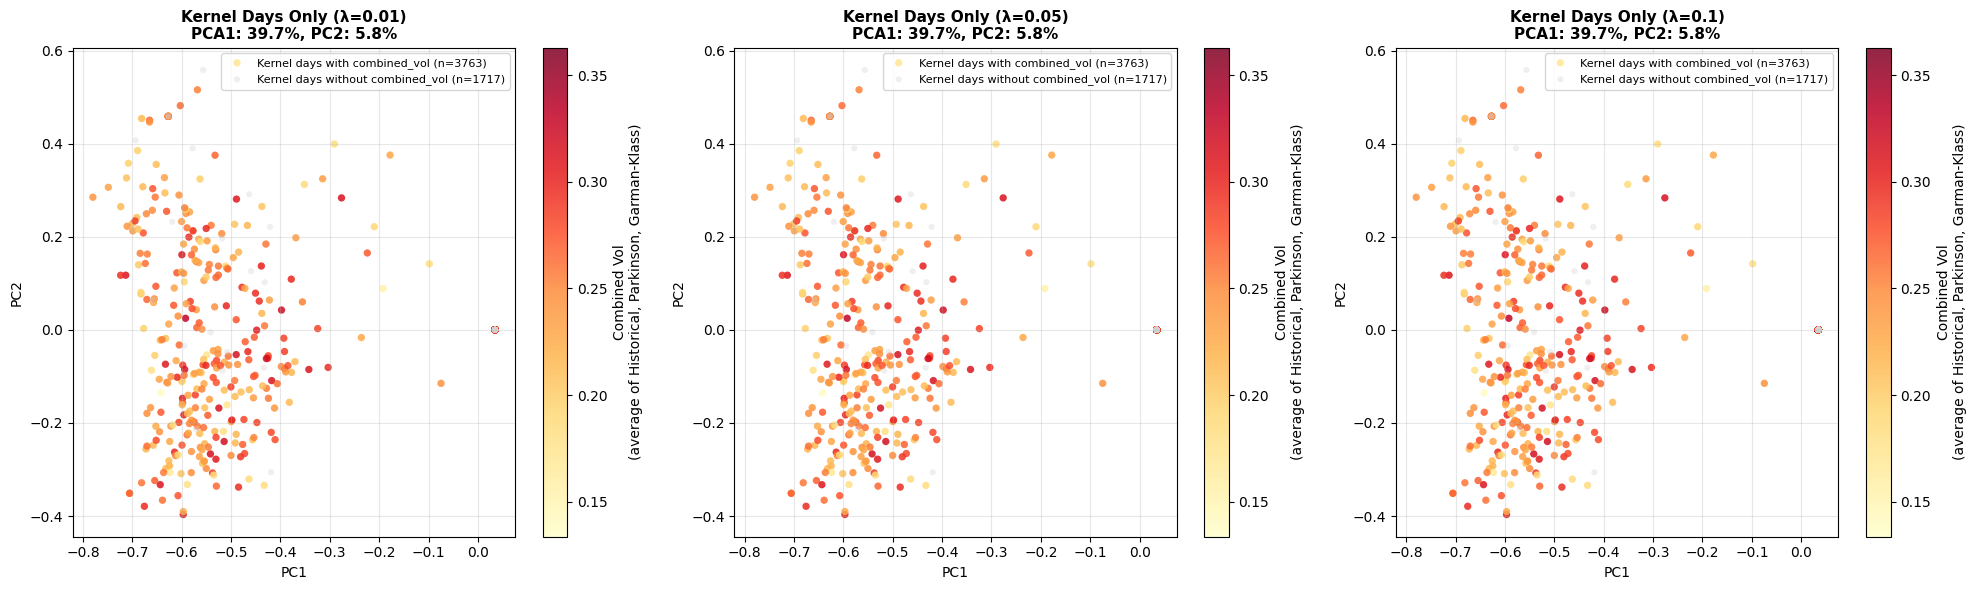

In [10]:
# Apply PCA for visualization (one for each lambda)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Force coloring by average of all volatility estimators
vol_col = 'combined_vol'
if vol_col not in vol_ts_clean.columns:
    raise ValueError("combined_vol not found. Run Cell 13 first to compute combined volatility.")

# Build volatility map from combined volatility only
vol_map_df = vol_ts_clean[['Date_norm', 'combined_vol']].drop_duplicates(subset=['Date_norm']).rename(
    columns={'Date_norm': 'date_norm'}
)

for idx, lam in enumerate(lambdas):
    ax = axes[idx]

    # Full kernel-aggregated context for ALL days in time_steps_range
    z_context_full = z_context_dict[lam]

    # PCA on kernel days only
    if z_context_full.shape[0] > 1 and z_context_full.shape[1] > 1:
        pca = PCA(n_components=2, random_state=42)
        x_2d_context_full = pca.fit_transform(z_context_full)
    else:
        x_2d_context_full = np.zeros((z_context_full.shape[0], 2))
        pca = None

    # Full daily context dataframe (all kernel days)
    kernel_plot_df = pd.DataFrame({
        'date': pd.to_datetime(time_steps_range),
        'x': x_2d_context_full[:, 0],
        'y': x_2d_context_full[:, 1]
    })
    kernel_plot_df['date_norm'] = kernel_plot_df['date'].dt.normalize()
    kernel_plot_df = kernel_plot_df.merge(vol_map_df, on='date_norm', how='left')

    # Color kernel days by combined volatility where available
    kernel_with_vol = kernel_plot_df.dropna(subset=[vol_col]).copy()
    if not kernel_with_vol.empty:
        q_low, q_high = kernel_with_vol[vol_col].quantile([0.05, 0.95])
        kernel_with_vol['vol_clip'] = kernel_with_vol[vol_col].clip(q_low, q_high)

        sc = ax.scatter(
            kernel_with_vol['x'],
            kernel_with_vol['y'],
            c=kernel_with_vol['vol_clip'],
            cmap='YlOrRd',
            alpha=0.85,
            s=28,
            edgecolors='none',
            label=f'Kernel days with combined_vol (n={len(kernel_with_vol)})',
            marker='o'
        )

        # Show remaining kernel days (no volatility available yet)
        kernel_no_vol = kernel_plot_df[kernel_plot_df[vol_col].isna()]
        if not kernel_no_vol.empty:
            ax.scatter(
                kernel_no_vol['x'],
                kernel_no_vol['y'],
                c='lightgray',
                alpha=0.35,
                s=20,
                edgecolors='none',
                label=f'Kernel days without combined_vol (n={len(kernel_no_vol)})',
                marker='o'
            )

        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label('Combined Vol\n(average of Historical, Parkinson, Garman-Klass)')
    else:
        ax.scatter(
            kernel_plot_df['x'],
            kernel_plot_df['y'],
            c='lightgray',
            alpha=0.5,
            s=22,
            edgecolors='none',
            label=f'Kernel days (all, n={len(kernel_plot_df)})',
            marker='o'
        )

    pca_info = f"\nPCA1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}" if pca else ""
    ax.set_title(f'Kernel Days Only (λ={lam}){pca_info}', fontweight='bold', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('images/kernel_days_combined_vol_colormap.png', dpi=150, bbox_inches='tight')
print("✓ Saved to images/kernel_days_combined_vol_colormap.png")
print(f"  Kernel context days shown (all): {len(time_steps_range)}")
print(f"  Kernel days with combined volatility: {kernel_plot_df['combined_vol'].notna().sum()}")
plt.show()


### Math Behind The Correlation Analysis

For each decay value $\lambda$, we take kernel context vectors over aligned days and reduce them to one principal component:

$$
\mathbf{z}_t^{(\lambda)} \in \mathbb{R}^D \;\xrightarrow{\text{PCA}}\; \text{PC1}_t
$$

So each day $t$ has:

- a scalar context score: $x_t = \text{PC1}_t$
- a volatility value: $y_t = \text{vol}_{20d,t}$

The reported number is the Pearson correlation:

$$
r_{x,y} = \frac{\sum_{t \in \mathcal{T}} (x_t-\bar{x})(y_t-\bar{y})}{\sqrt{\sum_{t \in \mathcal{T}} (x_t-\bar{x})^2}\sqrt{\sum_{t \in \mathcal{T}} (y_t-\bar{y})^2}}
$$

where $\mathcal{T}$ is the set of valid days (non-NaN volatility).

Interpretation:

- $r \approx +1$: higher kernel-context PC1 aligns with higher volatility.
- $r \approx -1$: higher PC1 aligns with lower volatility.
- $r \approx 0$: little linear relationship.

The cell also prints PCA explained variance:

$$
\text{ExplainedVariance(PC1)} = \frac{\lambda_1}{\sum_{j=1}^{D} \lambda_j}
$$

where $\lambda_1$ is the largest eigenvalue of the covariance matrix of kernel embeddings for that $\lambda$.

In [11]:
# Analyze correlation between kernel context and volatility
print("=== Kernel Aggregation Analysis ===\n")

for lam in lambdas:
    z_context = z_context_dict[lam]
    
    # Use only rows from merged_df
    z_context_subset = np.array([z_context[i] if i < len(z_context) else np.zeros(z_context.shape[1]) 
                                  for i in range(len(merged_df))])
    
    if z_context_subset.shape[0] > 1 and z_context_subset.shape[1] > 1:
        pca = PCA(n_components=1, random_state=42)
        pc1 = pca.fit_transform(z_context_subset).flatten()
        
        # Correlation with volatility
        valid_idx = ~np.isnan(merged_df['vol_20d'].values)
        if valid_idx.sum() > 1:
            corr = np.corrcoef(pc1[valid_idx], merged_df['vol_20d'].values[valid_idx])[0, 1]
            print(f"λ={lam}: PC1-Volatility correlation = {corr:.4f}")
        
        # Variance explained
        print(f"  Explained variance (PC1): {pca.explained_variance_ratio_[0]:.2%}")
        print()

# Summary statistics
print("Event Statistics:")
print(f"  Total news articles: {len(cluster_df)}")
print(f"  Date span: {cluster_df['date'].min().date()} to {cluster_df['date'].max().date()}")
print(f"  Days covered: {(cluster_df['date'].max() - cluster_df['date'].min()).days}")
print(f"  Avg articles per week: {len(cluster_df) / ((cluster_df['date'].max() - cluster_df['date'].min()).days / 7):.1f}")
print(f"  Embedding dimension: {x_text.shape[1]}")
print(f"\nVolatility Statistics:")
print(merged_df['vol_20d'].describe())

=== Kernel Aggregation Analysis ===

λ=0.01: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

λ=0.05: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

λ=0.1: PC1-Volatility correlation = 0.0060
  Explained variance (PC1): 40.76%

Event Statistics:
  Total news articles: 642
  Date span: 2010-04-15 to 2025-04-15
  Days covered: 5479
  Avg articles per week: 0.8
  Embedding dimension: 384

Volatility Statistics:
count    3763.000000
mean        0.263238
std         0.116479
min         0.082242
25%         0.189664
50%         0.241029
75%         0.303240
max         0.950589
Name: vol_20d, dtype: float64


## Sentiment Regime Detection (HMM)

A Hidden Markov Model identifies 3 latent sentiment states from text embeddings + market returns + volatility:

- **Bearish**: Negative sentiment, higher volatility, lower returns
- **Neutral**: Balanced conditions  
- **Bullish**: Positive sentiment, lower volatility, higher returns

The model learns transition probabilities (how likely regimes switch) and classification rules (which observations map to which regime).

Output:
- `regime_labels`: Daily regime (0/1/2) for each day
- `transitions`: Days when sentiment switched
- `metrics`: Average returns & Sharpe ratio per regime
- `forecast`: Predicted regimes using transition matrix


In [ ]:
import sys

# Reload hmm_regimes module to pick up latest changes
if 'hmm_regimes' in sys.modules:
    del sys.modules['hmm_regimes']

from models.hmm_regimes import (
    train_hmm_with_embeddings,
    classify_sentiment_regimes,
    detect_regime_transitions,
    sentiment_regime_metrics,
    forecast_regime,
    integrate_sentiment_regimes
)

# Align all data based on merged_df dates (which has both kernel context + volatility)
ts_aligned = ticker_to_df[ticker_for_vol].copy().sort_values('Date')
ts_aligned['Date_norm'] = ts_aligned['Date'].dt.normalize()
ts_aligned['returns'] = ts_aligned['Close'].pct_change()

# Merge time series with merged_df on date
aligned = ts_aligned.merge(
    merged_df[['date_norm', 'vol_20d', 'z_context_05']],
    left_on='Date_norm',
    right_on='date_norm',
    how='inner'
)
aligned = aligned.dropna(subset=['vol_20d', 'returns']).reset_index(drop=True)

# Extract aligned arrays (all same length now)
returns = aligned['returns'].values
volatility = aligned['vol_20d'].values
z_context = np.array(aligned['z_context_05'].tolist())

print(f"Aligned data: {len(returns)} days with matched embeddings, returns, and volatility")
print(f"  Returns shape: {returns.shape}")
print(f"  Volatility shape: {volatility.shape}")
print(f"  Embeddings shape: {z_context.shape}")

regime_labels, regime_stats, result = classify_sentiment_regimes(
    z_context, returns, volatility, random_state=42
)

print("\n" + "=" * 60)
print("SENTIMENT REGIME DETECTION (using Text Embeddings + Market)")
print("=" * 60)
print(f"\nHMM Log-Likelihood: {result.logprob:.2f}")
print(f"\nRegime Statistics:\n{regime_stats}\n")

print("Transition Probability Matrix (Bearish -> Neutral -> Bullish):")
print(result.transition_matrix)
print()

# Detect transitions
transitions = detect_regime_transitions(regime_labels)
print(f"Detected {len(transitions)} regime transitions:")
print(transitions.head(10))
print()

# Performance metrics by regime
metrics = sentiment_regime_metrics(returns, regime_labels)
print("Performance Metrics by Regime:")
for regime_name, regime_metrics_dict in metrics.items():
    print(f"\n{regime_name}:")
    for key, val in regime_metrics_dict.items():
        if isinstance(val, float):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

# Forecast next regimes
current_regime = regime_labels[-1]
sentiment_names = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}
forecast = forecast_regime(result.transition_matrix, current_regime, steps=5)
print(f"\nCurrent Regime: {sentiment_names[current_regime]}")
print(f"Forecasted Regimes (next 5 days): {[sentiment_names[r] for r in forecast]}")

Aligned data: 3763 days with matched embeddings, returns, and volatility
  Returns shape: (3763,)
  Volatility shape: (3763,)
  Embeddings shape: (3763, 384)

SENTIMENT REGIME DETECTION (using Text Embeddings + Market)

HMM Log-Likelihood: 567143.26

Regime Statistics:
   regime_id  mean_return  volatility  n_days  transition_prob_in    label
0          0    -0.000461    0.021564     128            0.399318  Bearish
1          1     0.000591    0.017919    3456            0.963252  Neutral
2          2     0.001666    0.017537     179            0.254055  Bullish

Transition Probability Matrix (Bearish -> Neutral -> Bullish):
[[0.39931775 0.2597999  0.34088234]
 [0.01107821 0.96325231 0.02566948]
 [0.22006421 0.52588092 0.25405487]]

Detected 338 regime transitions:
    idx  from_regime  to_regime from_sentiment to_sentiment     direction
0     1            2          1        Bullish      Neutral  bearish_turn
1   526            1          2        Neutral      Bullish  bullish_turn
2

## HMM Metrics & Performance Interpretation

### Key Metrics

**Regime Distribution**: Proportion of days in each sentiment state (Bearish/Neutral/Bullish)
- High Neutral dominance (>80%) is typical; extreme regimes are rarer

**Transition Matrix**: Probability of switching from regime $i$ to regime $j$
$$P_{ij} = P(\text{regime}_{t+1} = j \mid \text{regime}_t = i)$$
- Diagonal values show regime persistence (how long regimes last)
- Off-diagonal show transition probabilities between states
- High diagonal values = sticky regimes (slower switching)

**Regime Persistence**: Mean and median duration of each regime
- Measured by counting consecutive days in same regime
- Short duration = market sentiment is volatile
- Long duration = regime is stable

**Model Quality**:
- **Log-Likelihood**: How well the model explains observed data (higher is better, typically negative)
- **AIC/BIC**: Information criteria comparing fit vs complexity (lower is better)
- **Covariance Determinant**: Separation between regime clusters (larger = better separation)

**Performance Metrics Per Regime**:
- **Mean Return**: Annualized return during each regime
- **Win Rate**: Fraction of days with positive returns (vs 50% random)
- **Sharpe Ratio**: Return divided by volatility (risk-adjusted performance)
  - $\text{Sharpe} = \frac{\mu_r}{\sigma_r} \times \sqrt{252}$ (annualized)
  - High Sharpe = good returns with low volatility
  - Negative Sharpe = regime destroys value

✓ Saved dashboard to images/hmm_regime_analysis_dashboard.png


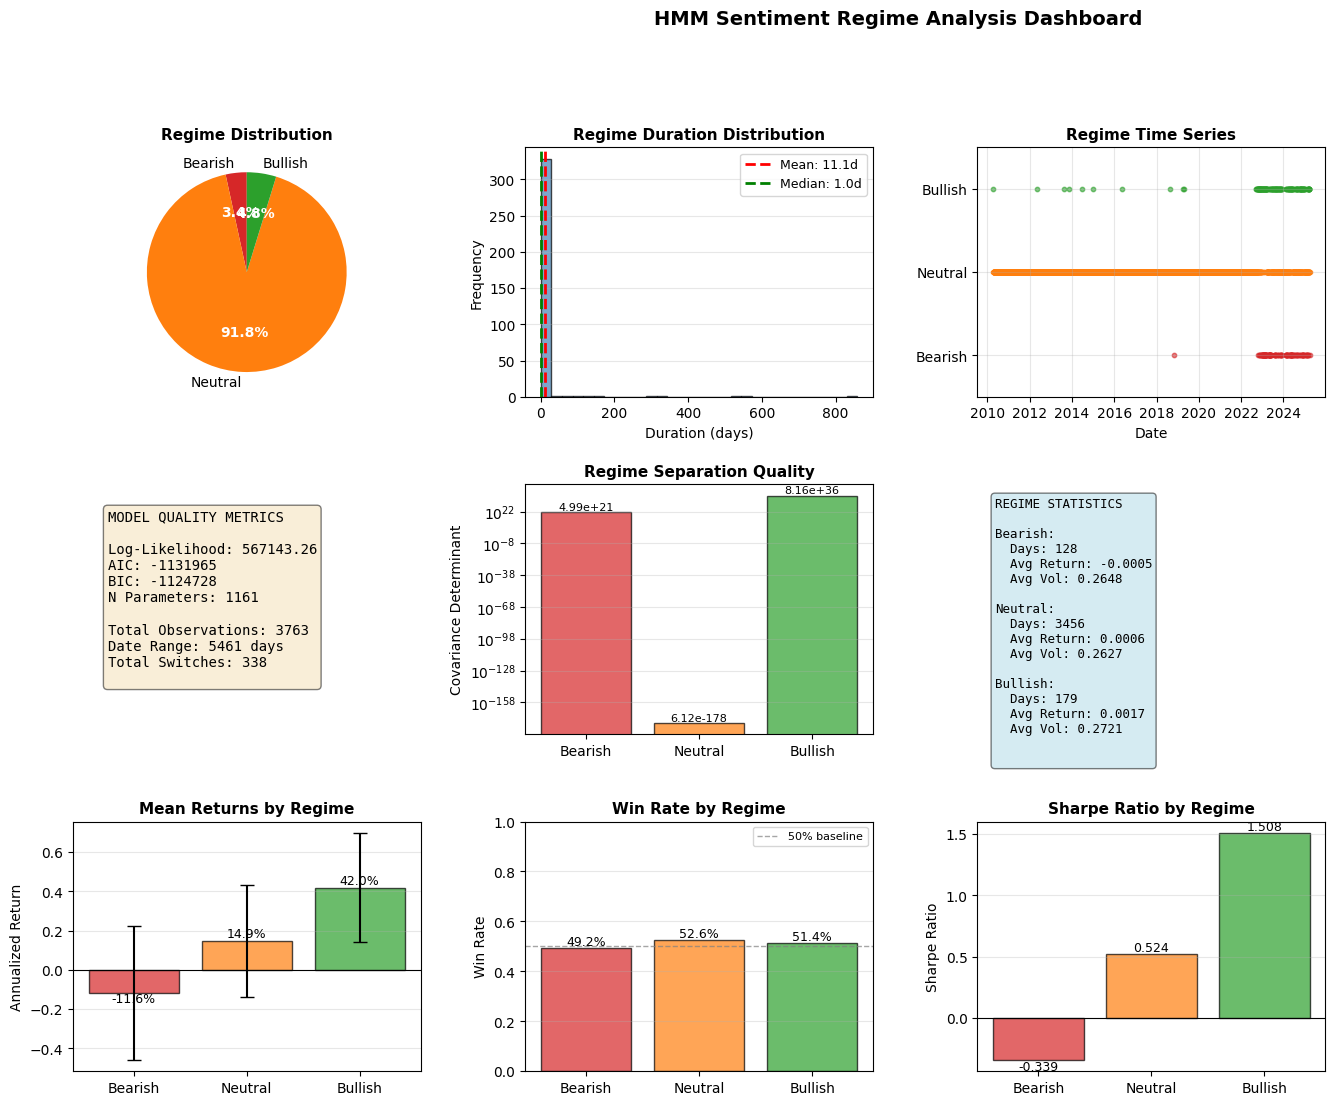

In [14]:
fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Compute required statistics
regime_counts = [np.sum(regime_labels == i) for i in range(3)]
regime_durations = []
current_regime = regime_labels[0]
current_duration = 1
for i in range(1, len(regime_labels)):
    if regime_labels[i] == current_regime:
        current_duration += 1
    else:
        regime_durations.append(current_duration)
        current_regime = regime_labels[i]
        current_duration = 1
regime_durations.append(current_duration)

n_features = z_context.shape[1]
logprob = result.logprob if hasattr(result, 'logprob') else 0.0
n_params = 3 * (n_features + 1) + 6
aic = -2 * logprob + 2 * n_params
bic = -2 * logprob + n_params * np.log(len(returns))

# 1. Regime Distribution (Pie Chart)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#d62728', '#ff7f0e', '#2ca02c']
wedges, texts, autotexts = ax1.pie(regime_counts, labels=[sentiment_names[i] for i in range(3)], 
                                     autopct='%1.1f%%', colors=colors, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Regime Distribution', fontweight='bold', fontsize=11)

# 2. Regime Persistence (Histogram)
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(regime_durations, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(regime_durations), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(regime_durations):.1f}d')
ax2.axvline(np.median(regime_durations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(regime_durations):.1f}d')
ax2.set_xlabel('Duration (days)')
ax2.set_ylabel('Frequency')
ax2.set_title('Regime Duration Distribution', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')

# 3. Regime Switches Over Time
ax3 = fig.add_subplot(gs[0, 2])
regime_colors_map = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c'}
dates_aligned = aligned['Date'].values
for i, regime_id in enumerate(regime_labels):
    ax3.scatter(dates_aligned[i], regime_id, color=regime_colors_map[regime_id], s=10, alpha=0.6)
ax3.set_ylim(-0.5, 2.5)
ax3.set_yticks([0, 1, 2])
ax3.set_yticklabels(['Bearish', 'Neutral', 'Bullish'])
ax3.set_xlabel('Date')
ax3.set_title('Regime Time Series', fontweight='bold', fontsize=11)
ax3.grid(alpha=0.3)

# 4. Model Quality Metrics
ax4 = fig.add_subplot(gs[1, 0])
ax4.axis('off')
quality_text = f"""MODEL QUALITY METRICS

Log-Likelihood: {logprob:.2f}
AIC: {aic:.0f}
BIC: {bic:.0f}
N Parameters: {int(n_params)}

Total Observations: {len(returns)}
Date Range: {(aligned['Date'].max() - aligned['Date'].min()).days} days
Total Switches: {len(transitions)}
"""
ax4.text(0.1, 0.9, quality_text, transform=ax4.transAxes, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 5. Regime Separation Quality
ax5 = fig.add_subplot(gs[1, 1])
cov_determinants = []
for i in range(3):
    cov = result.variances[i] if hasattr(result, 'variances') and result.variances is not None else np.eye(n_features)
    if np.isscalar(cov):
        determinant = cov
    else:
        determinant = np.linalg.det(cov) if cov.ndim > 0 else cov
    cov_determinants.append(determinant)

bars = ax5.bar([sentiment_names[i] for i in range(3)], cov_determinants, color=colors, edgecolor='black', alpha=0.7)
ax5.set_ylabel('Covariance Determinant', fontsize=10)
ax5.set_title('Regime Separation Quality', fontweight='bold', fontsize=11)
ax5.set_yscale('log')
ax5.grid(alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{cov_determinants[i]:.2e}', ha='center', va='bottom', fontsize=8)

# 6. Regime Statistics
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
regime_stats_text = "REGIME STATISTICS\n\n"
for regime_id in range(3):
    regime_mask = regime_labels == regime_id
    regime_stats_text += f"{sentiment_names[regime_id]}:\n"
    regime_stats_text += f"  Days: {np.sum(regime_mask)}\n"
    regime_stats_text += f"  Avg Return: {np.mean(returns[regime_mask]):.4f}\n"
    regime_stats_text += f"  Avg Vol: {np.mean(volatility[regime_mask]):.4f}\n\n"

ax6.text(0.05, 0.95, regime_stats_text, transform=ax6.transAxes, fontsize=9, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 7. Average Returns by Regime
ax7 = fig.add_subplot(gs[2, 0])
regime_returns_mean = []
regime_returns_std = []
for regime_id in range(3):
    regime_returns = returns[regime_labels == regime_id]
    regime_returns_mean.append(np.mean(regime_returns) * 252)
    regime_returns_std.append(np.std(regime_returns) * np.sqrt(252))

bars = ax7.bar([sentiment_names[i] for i in range(3)], regime_returns_mean, 
               yerr=regime_returns_std, color=colors, edgecolor='black', alpha=0.7, capsize=5)
ax7.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax7.set_ylabel('Annualized Return', fontsize=10)
ax7.set_title('Mean Returns by Regime', fontweight='bold', fontsize=11)
ax7.grid(alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{regime_returns_mean[i]:.1%}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

# 8. Win Rate by Regime
ax8 = fig.add_subplot(gs[2, 1])
win_rates = []
for regime_id in range(3):
    regime_returns = returns[regime_labels == regime_id]
    win_rate = np.sum(regime_returns > 0) / len(regime_returns)
    win_rates.append(win_rate)

bars = ax8.bar([sentiment_names[i] for i in range(3)], win_rates, color=colors, edgecolor='black', alpha=0.7)
ax8.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='50% baseline')
ax8.set_ylabel('Win Rate', fontsize=10)
ax8.set_ylim([0, 1])
ax8.set_title('Win Rate by Regime', fontweight='bold', fontsize=11)
ax8.grid(alpha=0.3, axis='y')
ax8.legend(fontsize=8)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{win_rates[i]:.1%}', ha='center', va='bottom', fontsize=9)

# 9. Sharpe Ratio by Regime
ax9 = fig.add_subplot(gs[2, 2])
sharpe_ratios = []
for regime_id in range(3):
    regime_returns = returns[regime_labels == regime_id]
    mean_ret = np.mean(regime_returns)
    vol_ret = np.std(regime_returns)
    sharpe = mean_ret / (vol_ret + 1e-8) * np.sqrt(252)
    sharpe_ratios.append(sharpe)

bars = ax9.bar([sentiment_names[i] for i in range(3)], sharpe_ratios, color=colors, edgecolor='black', alpha=0.7)
ax9.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax9.set_ylabel('Sharpe Ratio', fontsize=10)
ax9.set_title('Sharpe Ratio by Regime', fontweight='bold', fontsize=11)
ax9.grid(alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
            f'{sharpe_ratios[i]:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

plt.suptitle('HMM Sentiment Regime Analysis Dashboard', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('images/hmm_regime_analysis_dashboard.png', dpi=150, bbox_inches='tight')
print("✓ Saved dashboard to images/hmm_regime_analysis_dashboard.png")
plt.show()

# Naive Sentiment-Only Baseline

> This baseline is directly compared with the embedding-driven HMM. The **only change is the latent variable**:
- Embedding model uses `z_context` (kernel-aggregated text embeddings).
- Naive baseline uses **daily FinBERT sentiment probabilities** as `z_context_sentiment`.

> Returns and volatility inputs are identical across both models to isolate the effect of the latent representation.

## Approach: Pure News Sentiment Signal

We implement a naive approach using only news sentiment information from FinBERT. This simplified strategy:

1. **Ignores all technical indicators** (RSI, ATR, MACD, ADX, Bollinger Bands, etc.)
2. **Ignores temporal patterns and regime dynamics** from the HMM model
3. **Uses only the aggregated daily sentiment scores** from news articles

### Strategy Details

- **Signal**: Daily average FinBERT sentiment score (negative, neutral, positive)
- **Position**: Simple directional bet based on sentiment
  - Strong positive sentiment -> Long position
  - Neutral sentiment -> No position or flat
  - Strong negative sentiment -> Short position
- **Rebalancing**: Daily, at market open based on previous day's sentiment
- **No optimization**: No hyperparameter tuning, no ML models, purely rule-based

### Purpose

This baseline serves to:
1. **Quantify the value-add** of the embedding model over raw sentiment
2. **Isolate sentiment signal strength** independent of technical factors
3. **Provide a sanity check** that the embedding HMM outperforms naive sentiment trading
4. **Establish performance benchmarks** (Sharpe ratio, max drawdown, win rate) for comparison


FINBERT SENTIMENT ANALYSIS ON NEWS ARTICLES
Processing 16 texts from 642 unique dates



/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sample Analysis:
   ticker       date sentiment  sentiment_confidence
0       A 2025-03-03  negative              0.864276
1       A 2025-03-11  positive              0.918460
2       A 2025-03-11  positive              0.918460
3       A 2025-03-13   neutral              0.967990
4       A 2025-03-17  positive              0.741105
5       A 2025-03-18  positive              0.569180
6       A 2025-03-18  positive              0.921884
7       A 2025-03-21   neutral              0.943868
8       A 2025-03-21  positive              0.918449
9       A 2025-03-26  negative              0.820364
10      A 2025-03-28  positive              0.759083
11      A 2025-03-28  positive              0.571765
12      A 2025-03-28   neutral              0.944055
13      A 2025-04-02  positive              0.932729
14      A 2025-04-11  positive              0.905725

Sentiment Distribution:
sentiment
positive    11
neutral      3
negative     2
Name: count, dtype: int64

✓ Aligned 3763 sentiment sco


HMM SENTIMENT-ONLY BASELINE (LATENT = FinBERT PROBS)

HMM Log-Likelihood (Sentiment-Only): 51130.90
Embedding HMM Log-Likelihood: 567143.26

Regime Statistics (Sentiment-Only):
   regime_id  mean_return  volatility  n_days  transition_prob_in    label
0          0    -0.012839    0.006524       3            0.998136  Bearish
1          1    -0.001321    0.010644       5            0.249999  Neutral
2          2     0.000620    0.018050    3755            0.000000  Bullish

✓ Saved: images/hmm_sentiment_only_baseline.png

COMPARISON: EMBEDDING HMM vs SENTIMENT-ONLY HMM
                Embedding HMM  Sentiment-Only
Log-Likelihood  567143.263192    51130.901522
Active Regimes       3.000000        3.000000


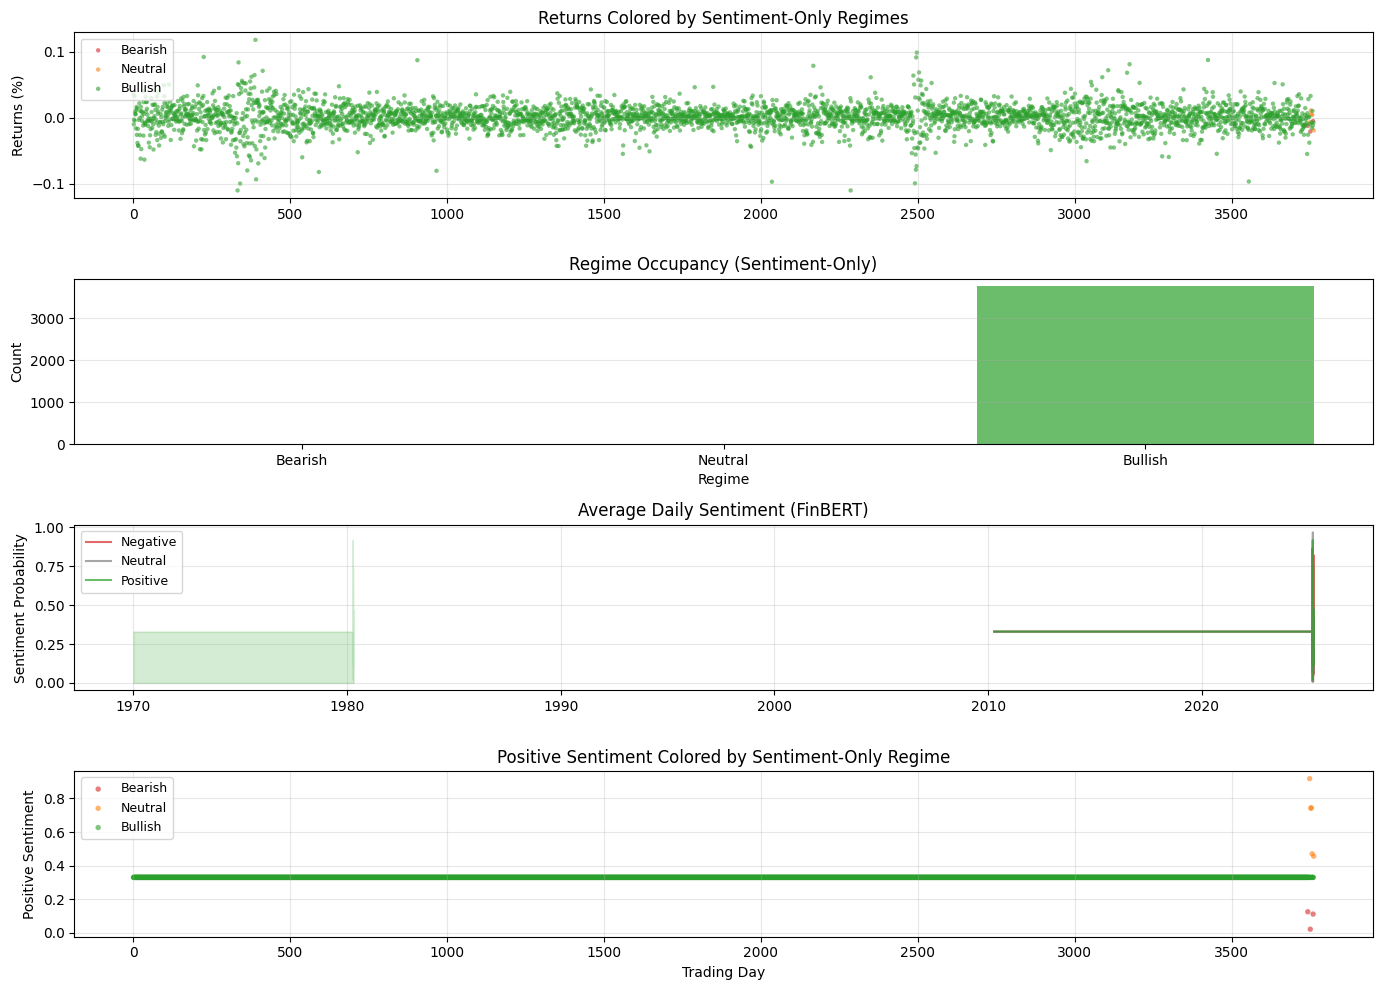

In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import sys
sys.path.insert(0, str(Path.cwd()))
from models.hmm_regimes import classify_sentiment_regimes

texts_per_ticker = 16
batch_size = 8

news_sentiment_map = (
    text_alignment_df[["ticker", "date", "text"]]
    .copy()
    .assign(
        ticker=lambda d: d["ticker"].astype(str),
        date=lambda d: pd.to_datetime(d["date"], errors="coerce"),
        text=lambda d: d["text"].fillna("").astype(str),
    )
    .dropna(subset=["date"])
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
 )

if texts_per_ticker is not None and texts_per_ticker > 0:
    news_sentiment_map = (
        news_sentiment_map.groupby("ticker", group_keys=False)
        .tail(texts_per_ticker)
        .reset_index(drop=True)
    )

print(f"\n{'='*70}")
print("FINBERT SENTIMENT ANALYSIS ON NEWS ARTICLES")
print(f"{'='*70}")
print(f"Processing {len(news_sentiment_map)} texts from {len(cluster_df)} unique dates\n")

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
finbert_model.eval()

label_map = {0: "negative", 1: "neutral", 2: "positive"}
all_probs = []

with torch.no_grad():
    texts = news_sentiment_map["text"].tolist()
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256,
        )
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.append(probs)

if all_probs:
    probs_np = np.vstack(all_probs)
else:
    probs_np = np.zeros((len(news_sentiment_map), 3), dtype=float)

news_sentiment_map["negative"] = probs_np[:, 0]
news_sentiment_map["neutral"] = probs_np[:, 1]
news_sentiment_map["positive"] = probs_np[:, 2]
news_sentiment_map["sentiment"] = [label_map[i] for i in probs_np.argmax(axis=1)]
news_sentiment_map["sentiment_confidence"] = probs_np.max(axis=1)

print("Sample Analysis:")
print(news_sentiment_map[["ticker", "date", "sentiment", "sentiment_confidence"]].head(15))
print(f"\nSentiment Distribution:")
print(news_sentiment_map['sentiment'].value_counts())

sentiment_by_date = (
    news_sentiment_map
    .groupby("date")[["negative", "neutral", "positive"]]
    .mean()
    .reset_index()
 )
sentiment_by_date = sentiment_by_date.sort_values("date")
sentiment_by_date["date"] = pd.to_datetime(sentiment_by_date["date"])

hmm_aligned_dates = pd.to_datetime(meta_df['date'].values)
sentiment_aligned = []
for date in hmm_aligned_dates:
    match = sentiment_by_date[sentiment_by_date["date"] == date]
    if len(match) > 0:
        sentiment_aligned.append({
            "negative": match["negative"].values[0],
            "neutral": match["neutral"].values[0],
            "positive": match["positive"].values[0]
        })
    else:
        sentiment_aligned.append({"negative": 0.33, "neutral": 0.33, "positive": 0.33})

sentiment_aligned_df = pd.DataFrame(sentiment_aligned)
print(f"\n✓ Aligned {len(sentiment_aligned_df)} sentiment scores to {len(returns)} HMM returns")

z_context_sentiment = sentiment_aligned_df[["negative", "neutral", "positive"]].values

if "regime_labels" not in globals() or "result" not in globals():
    regime_labels, regime_stats, result = classify_sentiment_regimes(
        z_context, returns, volatility, random_state=42
    )

regime_labels_sent, regime_stats_sent, result_sent = classify_sentiment_regimes(
    z_context_sentiment, returns, volatility, random_state=42
 )

print(f"\n{'='*70}")
print("HMM SENTIMENT-ONLY BASELINE (LATENT = FinBERT PROBS)")
print(f"{'='*70}")
print(f"\nHMM Log-Likelihood (Sentiment-Only): {result_sent.logprob:.2f}")
print(f"Embedding HMM Log-Likelihood: {result.logprob:.2f}")

regime_labels_sent_arr = regime_labels_sent.astype(int)
counts_sent = np.bincount(regime_labels_sent_arr)
sentiment_names = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}

print(f"\nRegime Statistics (Sentiment-Only):")
print(regime_stats_sent)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

regime_colors_sent = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c'}
dates = hmm_aligned_dates

ax = axes[0]
for regime in range(3):
    mask = regime_labels_sent_arr == regime
    ax.scatter(np.where(mask)[0], returns[mask], c=regime_colors_sent[regime], 
               label=sentiment_names[regime], s=10, alpha=0.6, edgecolors='none')
ax.set_ylabel('Returns (%)')
ax.set_title('Returns Colored by Sentiment-Only Regimes')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(range(3), counts_sent, color=[regime_colors_sent[i] for i in range(3)], alpha=0.7)
ax.set_ylabel('Count')
ax.set_xlabel('Regime')
ax.set_title('Regime Occupancy (Sentiment-Only)')
ax.set_xticks(range(3))
ax.set_xticklabels([sentiment_names[i] for i in range(3)])
ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
ax.plot(dates, sentiment_aligned_df["negative"].values, label="Negative", color='#d62728', linewidth=1.5, alpha=0.7)
ax.plot(dates, sentiment_aligned_df["neutral"].values, label="Neutral", color='gray', linewidth=1.5, alpha=0.7)
ax.plot(dates, sentiment_aligned_df["positive"].values, label="Positive", color='#2ca02c', linewidth=1.5, alpha=0.7)
ax.fill_between(range(len(dates)), 0, sentiment_aligned_df["positive"].values, alpha=0.2, color='#2ca02c')
ax.set_ylabel('Sentiment Probability')
ax.set_title('Average Daily Sentiment (FinBERT)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[3]
for regime in range(3):
    mask = regime_labels_sent_arr == regime
    positions = np.where(mask)[0]
    ax.scatter(positions, sentiment_aligned_df["positive"].values[mask], 
               c=regime_colors_sent[regime], label=sentiment_names[regime], s=15, alpha=0.6, edgecolors='none')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Positive Sentiment')
ax.set_title('Positive Sentiment Colored by Sentiment-Only Regime')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/hmm_sentiment_only_baseline.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: images/hmm_sentiment_only_baseline.png")

print(f"\n{'='*70}")
print("COMPARISON: EMBEDDING HMM vs SENTIMENT-ONLY HMM")
print(f"{'='*70}")
comparison_mod = pd.DataFrame({
    'Embedding HMM': [result.logprob, len(np.unique(regime_labels))],
    'Sentiment-Only':  [result_sent.logprob, len(np.unique(regime_labels_sent_arr))]
}, index=['Log-Likelihood', 'Active Regimes'])
print(comparison_mod)
print(f"{'='*70}")

/tmp/ipykernel_16600/2674838283.py:19: RuntimeWarning: All-NaN slice encountered
  max_dd = np.nanmin(drawdown)



PERFORMANCE METRICS BY SENTIMENT-MODULATED REGIME

 Regime  Mean Daily Return  Daily Volatility  Annual Return  Annual Volatility  Sharpe Ratio  Sortino Ratio  Max Drawdown  Calmar Ratio  Win Rate  Avg Win  Avg Loss  Total Return  N Obs
Bearish           0.000694          0.016257       0.174817           0.258067      0.677408       1.103564     -0.111565      1.566944  0.484375 0.012563  0.011131           NaN    128
Neutral           0.000450          0.031151       0.113319           0.494513      0.229152       0.325467     -0.504753      0.224503  0.502315 0.020397  0.020116           NaN   3456
Bullish          -0.000869          0.016058      -0.219090           0.254916     -0.859460      -1.032071           NaN           NaN  0.483146 0.010556  0.011677           NaN    178

METRIC DEFINITIONS

Sharpe Ratio = (Mean Return / Daily Volatility) * sqrt(252)
  → Risk-adjusted return. Higher is better. Threshold: >1 is good, >2 is excellent

Sortino Ratio = (Mean Return / Downside

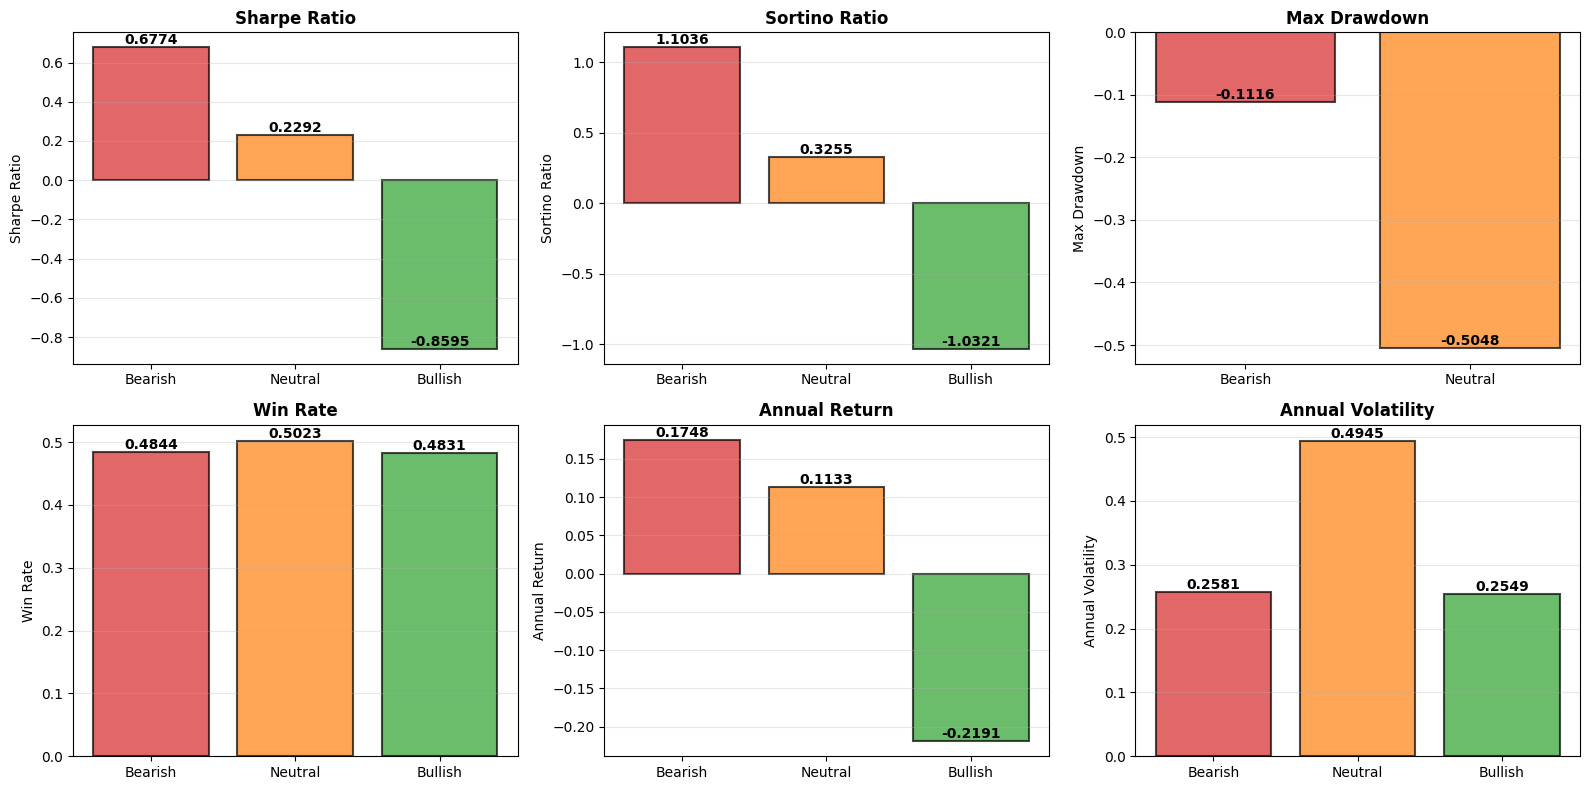

In [46]:
returns_daily = ticker_data_full['Close'].pct_change().values
aligned_returns = returns_daily[aligned_indicators.index.values] if len(aligned_indicators) <= len(returns_daily) else returns_daily[aligned_indicators.index.values[:len(returns_daily)]]
cumulative_returns = np.cumprod(1 + aligned_returns) - 1

performance_data = []
regime_names = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}

for regime in range(3):
    mask = regime_labels_mod_arr == regime
    regime_returns = aligned_returns[mask]
    regime_cumrets = cumulative_returns[mask]
    
    mean_return = np.nanmean(regime_returns)
    std_return = np.nanstd(regime_returns)
    sharpe_ratio = (mean_return / std_return * np.sqrt(252)) if std_return > 0 else 0
    
    cummax = np.maximum.accumulate(1 + regime_returns)
    drawdown = (1 + regime_returns) / cummax - 1
    max_dd = np.nanmin(drawdown)
    
    downside_returns = regime_returns[regime_returns < 0]
    downside_std = np.nanstd(downside_returns) if len(downside_returns) > 0 else 0
    sortino_ratio = (mean_return / downside_std * np.sqrt(252)) if downside_std > 0 else 0
    
    calmar_ratio = (mean_return * 252) / abs(max_dd) if max_dd != 0 else 0
    
    win_rate = np.sum(regime_returns > 0) / len(regime_returns[~np.isnan(regime_returns)]) if len(regime_returns) > 0 else 0
    
    win_returns = regime_returns[regime_returns > 0]
    loss_returns = regime_returns[regime_returns < 0]
    avg_win = np.nanmean(win_returns) if len(win_returns) > 0 else 0
    avg_loss = np.nanmean(loss_returns) if len(loss_returns) > 0 else 0
    
    total_return = regime_cumrets[-1] if len(regime_cumrets) > 0 else 0
    
    performance_data.append({
        'Regime': regime_names[regime],
        'Mean Daily Return': mean_return,
        'Daily Volatility': std_return,
        'Annual Return': mean_return * 252,
        'Annual Volatility': std_return * np.sqrt(252),
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar_ratio,
        'Win Rate': win_rate,
        'Avg Win': avg_win,
        'Avg Loss': abs(avg_loss),
        'Total Return': total_return,
        'N Obs': np.sum(~np.isnan(regime_returns))
    })

perf_df = pd.DataFrame(performance_data)

print(f"\n{'='*100}")
print("PERFORMANCE METRICS BY SENTIMENT-MODULATED REGIME")
print(f"{'='*100}\n")
print(perf_df.to_string(index=False))

print(f"\n{'='*100}")
print("METRIC DEFINITIONS")
print(f"{'='*100}")
print("""
Sharpe Ratio = (Mean Return / Daily Volatility) * sqrt(252)
  → Risk-adjusted return. Higher is better. Threshold: >1 is good, >2 is excellent
  
Sortino Ratio = (Mean Return / Downside Volatility) * sqrt(252)
  → Like Sharpe but only penalizes downside volatility. Often > Sharpe
  
Max Drawdown = Worst peak-to-trough decline
  → Maximum loss from peak. Lower (more negative) is worse
  
Calmar Ratio = (Annual Return) / |Max Drawdown|
  → Return per unit of drawdown risk. Higher is better
  
Win Rate = % of days with positive returns
  → Basic profitability metric. >50% is good
  
Avg Win vs Avg Loss = Average size of winning vs losing days
  → Profit factor = Avg Win / Avg Loss. >1.5 is strong
  
Total Return = Cumulative return over the regime period
  → Total P&L if held from start to end of regime
""")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

metrics_to_plot = [
    ('Sharpe Ratio', 'Sharpe Ratio'),
    ('Sortino Ratio', 'Sortino Ratio'),
    ('Max Drawdown', 'Max Drawdown'),
    ('Win Rate', 'Win Rate'),
    ('Annual Return', 'Annual Return'),
    ('Annual Volatility', 'Annual Volatility')
]

colors = ['#d62728', '#ff7f0e', '#2ca02c']

for idx, (metric_name, col) in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    values = perf_df[col].values
    bars = ax.bar(regime_names.values(), values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_title(metric_name, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/performance_metrics_by_regime.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: images/performance_metrics_by_regime.png")

# HMM Alpha Comparison: Embeddings vs News Sentiment

This section compares the **HMM alpha** (stationary state probabilities) between:
- **Embedding HMM** (latent = kernel-aggregated text embeddings)
- **Sentiment-Only HMM** (latent = FinBERT sentiment probabilities)

Both models use the same **returns** and **volatility** inputs. Only the latent representation changes.

## 1. Basic decomposition
$$
y_t = f_\beta(X_t^\beta) + f_\alpha(X_t^\alpha) + \epsilon_t
$$

- $X_t^\beta$: market + regime features (returns, volatility, HMM regimes)
- $X_t^\alpha$: text features (embeddings, drift, disagreement)
- $\epsilon_t$: noise

## 2. Linear factor view
$$
y_t = \alpha + \beta^\top F_t + \epsilon_t
$$
$$
y_t = \alpha + \beta^\top F_t + \gamma^\top Z_t + \epsilon_t
$$

- $\beta^\top F_t$ = beta (systematic)
- $\gamma^\top Z_t$ = incremental alpha from text
- $\alpha$ = unconditional alpha

## 3. Residual-based alpha (core test)
1) Fit beta model: $\hat{y}_t^\beta = f_\beta(X_t^\beta)$
2) Residuals: $r_t = y_t - \hat{y}_t^\beta$
3) Alpha model: $\hat{r}_t = f_\alpha(X_t^\alpha)$

$$
R_\alpha^2 = 1 - \frac{\sum_t (r_t - \hat{r}_t)^2}{\sum_t r_t^2}
$$

If $R_\alpha^2 > 0$, text explains residual structure (true alpha).

## 4. Orthogonal projection view
Let $Y$ be the target, $X_\beta$ beta features, $X_\alpha$ text features.
$$
\hat{Y}_\beta = P_\beta Y = X_\beta (X_\beta^\top X_\beta)^{-1} X_\beta^\top Y
$$
$$
R = Y - \hat{Y}_\beta \quad (R \perp X_\beta)
$$
$$
\hat{R} = P_\alpha R
$$
$$
Y = P_\beta Y + P_\alpha (I - P_\beta) Y + \epsilon
$$

## 5. Incremental explanatory power
$$
\Delta R^2 = R^2(X_\beta, X_\alpha) - R^2(X_\beta)
$$

## 6. Conditional alpha with regimes
Let $S_t$ be the HMM regime:
$$
y_t = \beta_{S_t}^\top F_t + \gamma_{S_t}^\top Z_t + \epsilon_t
$$
We test if $\gamma_{S_t} \ne 0$ per regime.

## Practical metrics
- Incremental $R^2$: $R^2_{\text{beta}}$, $R^2_{\text{beta+text}}$, $\Delta R^2$
- Information Coefficient: $IC = \mathrm{corr}(\hat{y}, y)$
- Sharpe (simple trading): $\mathrm{sign}(\hat{y}_t)$
- Residual plot: predicted residual vs actual residual

     State  Embedding HMM  Sentiment-Only HMM
0  Bearish       0.034253            0.997786
1  Neutral       0.918486            0.001417
2  Bullish       0.047260            0.000797
     Metric      Beta  Beta+Text  Alpha (Residual)
0        R2  0.002052   0.002446               NaN
1        IC  0.047458   0.051734          0.020336
2    Sharpe  0.775900   0.883631         -0.022682
3  R2_Alpha       NaN        NaN          0.000387
Delta R2: 0.000394
Saved: images/hmm_alpha_comparison.png


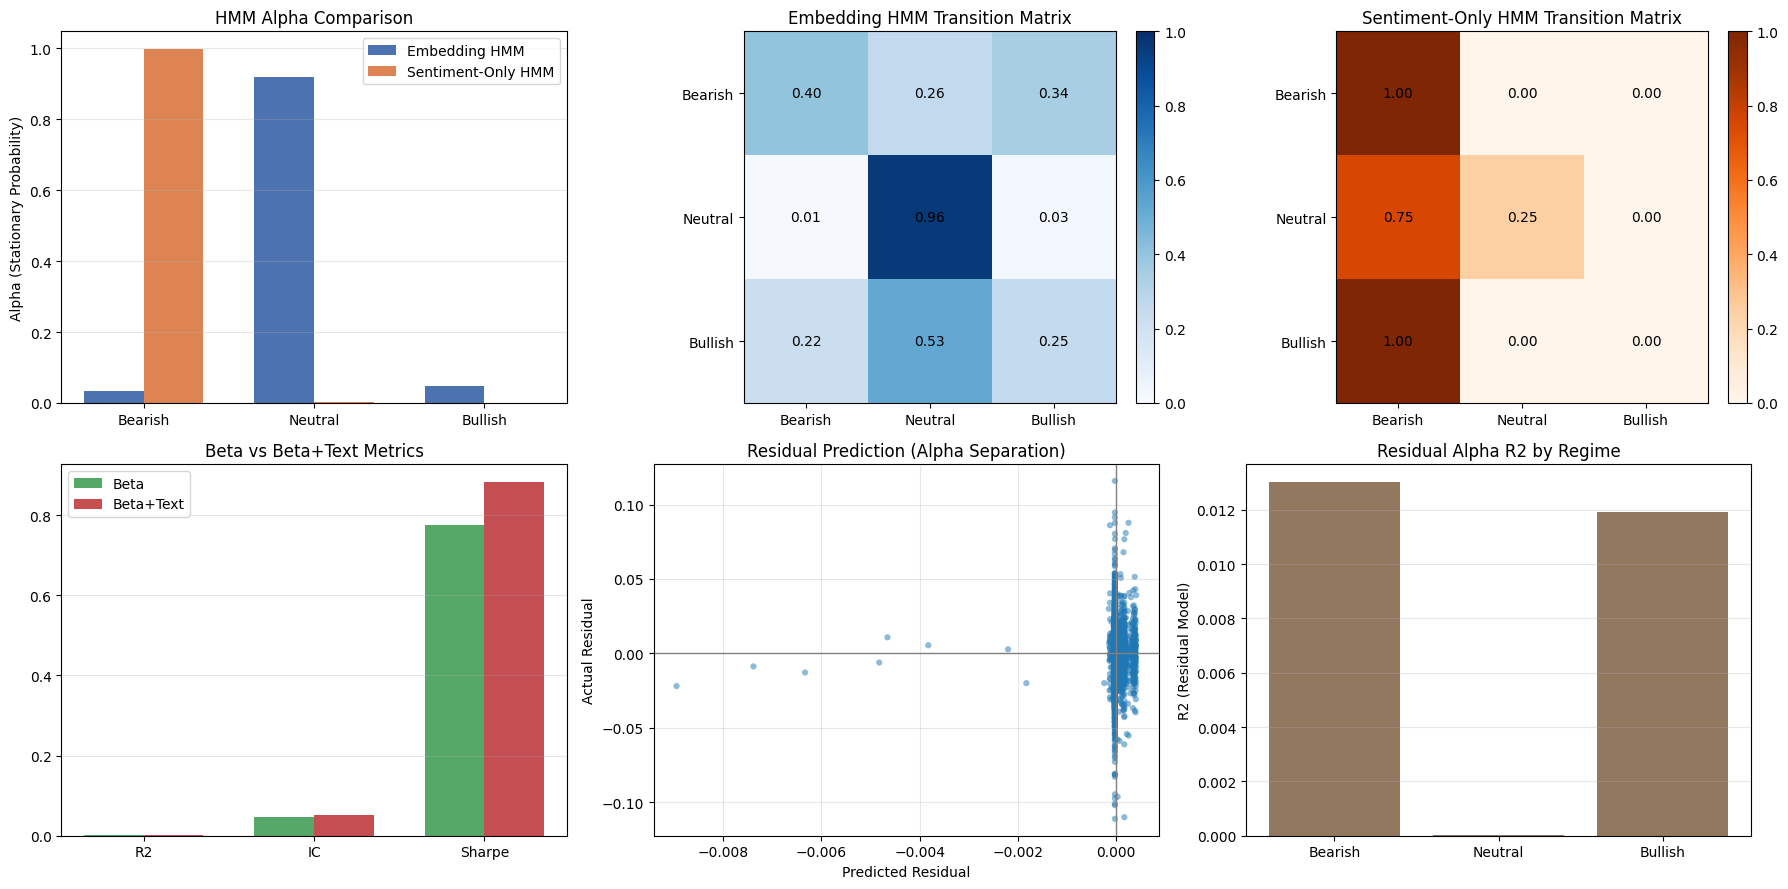

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def stationary_distribution(transition_matrix):
    eigvals, eigvecs = np.linalg.eig(transition_matrix.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    stationary = np.real(eigvecs[:, idx])
    stationary = np.maximum(stationary, 0)
    if stationary.sum() == 0:
        stationary = np.ones_like(stationary)
    return stationary / stationary.sum()

required_vars = ["result", "result_sent", "returns", "volatility", "regime_labels", "z_context", "sentiment_aligned_df"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"Missing required variables: {missing_vars}")

alpha_embed = stationary_distribution(result.transition_matrix)
alpha_sent = stationary_distribution(result_sent.transition_matrix)

alpha_df = pd.DataFrame({
    "State": ["Bearish", "Neutral", "Bullish"],
    "Embedding HMM": alpha_embed,
    "Sentiment-Only HMM": alpha_sent
})

print(alpha_df)

returns_arr = np.asarray(returns)
vol_arr = np.asarray(volatility)
regimes_arr = np.asarray(regime_labels)
z_context_arr = np.asarray(z_context)
sent_probs = sentiment_aligned_df[["negative", "neutral", "positive"]].values

n = min(len(returns_arr), len(vol_arr), len(regimes_arr), len(z_context_arr), len(sent_probs))
returns_arr = returns_arr[:n]
vol_arr = vol_arr[:n]
regimes_arr = regimes_arr[:n]
z_context_arr = z_context_arr[:n]
sent_probs = sent_probs[:n]

y = returns_arr[1:n]
lag_ret = returns_arr[:n-1]
lag_vol = vol_arr[:n-1]
regime_t = regimes_arr[1:n].astype(int)
regime_onehot = np.eye(3)[regimes_arr[:n-1].astype(int)]
X_beta = np.column_stack([lag_ret, lag_vol, regime_onehot])

emb_drift = np.linalg.norm(z_context_arr[1:n] - z_context_arr[:n-1], axis=1)
z_norm = np.linalg.norm(z_context_arr, axis=1)
sem_vol = pd.Series(z_norm).rolling(20).std().values
sem_vol = sem_vol[1:n]
entropy = -np.sum(sent_probs * np.log(sent_probs + 1e-12), axis=1)
entropy = entropy[1:n]
X_alpha = np.column_stack([emb_drift, sem_vol, entropy])
X_full = np.column_stack([X_beta, X_alpha])

mask = np.isfinite(y) & np.isfinite(X_beta).all(axis=1) & np.isfinite(X_full).all(axis=1)
y = y[mask]
X_beta = X_beta[mask]
X_alpha = X_alpha[mask]
X_full = X_full[mask]
regime_t = regime_t[mask]

beta_model = Ridge(alpha=1.0)
full_model = Ridge(alpha=1.0)
alpha_model = Ridge(alpha=1.0)

beta_model.fit(X_beta, y)
pred_beta = beta_model.predict(X_beta)
residuals = y - pred_beta

alpha_model.fit(X_alpha, residuals)
pred_alpha = alpha_model.predict(X_alpha)
residuals_hat = pred_alpha

full_model.fit(X_full, y)
pred_full = full_model.predict(X_full)

r2_beta = r2_score(y, pred_beta)
r2_full = r2_score(y, pred_full)
delta_r2 = r2_full - r2_beta
r2_alpha = r2_score(residuals, residuals_hat)

ic_beta = np.corrcoef(pred_beta, y)[0, 1]
ic_full = np.corrcoef(pred_full, y)[0, 1]
ic_alpha = np.corrcoef(residuals_hat, residuals)[0, 1]

pos_beta = np.sign(pred_beta)
pos_full = np.sign(pred_full)
pos_alpha = np.sign(residuals_hat)
ret_beta = pos_beta * y
ret_full = pos_full * y
ret_alpha = pos_alpha * residuals

sharpe_beta = np.mean(ret_beta) / (np.std(ret_beta) + 1e-12) * np.sqrt(252)
sharpe_full = np.mean(ret_full) / (np.std(ret_full) + 1e-12) * np.sqrt(252)
sharpe_alpha = np.mean(ret_alpha) / (np.std(ret_alpha) + 1e-12) * np.sqrt(252)

metrics_df = pd.DataFrame({
    "Metric": ["R2", "IC", "Sharpe", "R2_Alpha"],
    "Beta": [r2_beta, ic_beta, sharpe_beta, np.nan],
    "Beta+Text": [r2_full, ic_full, sharpe_full, np.nan],
    "Alpha (Residual)": [np.nan, ic_alpha, sharpe_alpha, r2_alpha]
})

print(metrics_df)
print(f"Delta R2: {delta_r2:.6f}")

regime_alpha = []
for k in range(3):
    idx = regime_t == k
    if idx.sum() < 30:
        regime_alpha.append(np.nan)
        continue
    y_k = y[idx]
    Xb_k = X_beta[idx]
    Xa_k = X_alpha[idx]
    beta_k = Ridge(alpha=1.0)
    alpha_k = Ridge(alpha=1.0)
    beta_k.fit(Xb_k, y_k)
    res_k = y_k - beta_k.predict(Xb_k)
    alpha_k.fit(Xa_k, res_k)
    pred_k = alpha_k.predict(Xa_k)
    regime_alpha.append(r2_score(res_k, pred_k))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

ax = axes[0, 0]
x = np.arange(len(alpha_df["State"]))
width = 0.35
ax.bar(x - width / 2, alpha_embed, width, label="Embedding HMM", color="#4C72B0")
ax.bar(x + width / 2, alpha_sent, width, label="Sentiment-Only HMM", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(alpha_df["State"])
ax.set_ylabel("Alpha (Stationary Probability)")
ax.set_title("HMM Alpha Comparison")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[0, 1]
im1 = ax.imshow(result.transition_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_title("Embedding HMM Transition Matrix")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["Bearish", "Neutral", "Bullish"])
ax.set_yticklabels(["Bearish", "Neutral", "Bullish"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{result.transition_matrix[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0, 2]
im2 = ax.imshow(result_sent.transition_matrix, cmap="Oranges", vmin=0, vmax=1)
ax.set_title("Sentiment-Only HMM Transition Matrix")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["Bearish", "Neutral", "Bullish"])
ax.set_yticklabels(["Bearish", "Neutral", "Bullish"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{result_sent.transition_matrix[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 0]
labels = ["R2", "IC", "Sharpe"]
beta_vals = [r2_beta, ic_beta, sharpe_beta]
full_vals = [r2_full, ic_full, sharpe_full]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, beta_vals, width, label="Beta", color="#55A868")
ax.bar(x + width / 2, full_vals, width, label="Beta+Text", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Beta vs Beta+Text Metrics")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

residual_pred = residuals_hat
residual_actual = residuals
ax = axes[1, 1]
ax.scatter(residual_pred, residual_actual, alpha=0.5, s=20, edgecolors="none")
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Predicted Residual")
ax.set_ylabel("Actual Residual")
ax.set_title("Residual Prediction (Alpha Separation)")
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.bar(["Bearish", "Neutral", "Bullish"], regime_alpha, color="#937860")
ax.set_title("Residual Alpha R2 by Regime")
ax.set_ylabel("R2 (Residual Model)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("images/hmm_alpha_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: images/hmm_alpha_comparison.png")

# Technical Indicators Colored by Sentiment-Modulated Regimes

## Temporal Analysis: Technical Indicators & MOMENT Embeddings

### Multi-Channel Time Series Representation

Encode market microstructure using 44 technical channels:

- **Trends**: SMA-20, SMA-50, EMA-12, EMA-26, HMA-9
- **Oscillators**: RSI-14, MACD, Stochastic, Stochastic-RSI, ADX, Williams-%R  
- **Volatility**: ATR-14, Bollinger Bands (5 metrics), Keltner Channels (4 metrics)
- **Drawdown**: Donchian Channels (4 metrics), Bull/Bear Power
- **Advanced**: Awesome Oscillator, Momentum, ROC, Parkinson Vol, Garman-Klass Vol

### MOMENT Deep Encoding

Transform 60-day rolling windows through a Transformer-based model:

- **Input**: [B × 44 channels × T timesteps] (B = batch, T = sequence length)
- **Transpose**: Convert to [B × T × 44] for temporal attention
- **Output**: Learned embeddings capturing temporal dependencies
- **Visualization**: PCA reduces to 2D, colored by realized volatility

### Information Fusion

Combines three data modalities:
1. **News embeddings** (sparse events → kernel aggregation)
2. **Technical indicators** (dense daily features)
3. **MOMENT representations** (deep temporal patterns)

This enables multi-scale regime detection: rapid sentiment shifts + sustained technical trends.

In [15]:
from features.technical import (
    sma, ema, hma, rsi, stochastic, atr, adx, macd, 
    awesome_oscillator, momentum, roc, bollinger_bands,
    rolling_volatility, stochastic_rsi, williams_r,
    keltner_channels, donchian_channels, bull_bear_power,
    parkinson_volatility, garman_klass_volatility
)

print(f"Computing technical indicators for {len(ticker_to_df)} tickers...")

for ticker, df in ticker_to_df.items():
    close = df['Close'].astype(float)
    high = df['High'].astype(float)
    low = df['Low'].astype(float)
    volume = df['Volume'].astype(float)
    open_ = df['Open'].astype(float)
    
    df['sma_20'] = sma(close, 20)
    df['sma_50'] = sma(close, 50)
    df['ema_12'] = ema(close, 12)
    df['ema_26'] = ema(close, 26)
    df['hma_9'] = hma(close, 9)
    
    df['rsi_14'] = rsi(close, 14)
    
    macd_df = macd(close)
    df['macd'] = macd_df['macd']
    df['macd_signal'] = macd_df['signal']
    df['macd_hist'] = macd_df['histogram']
    
    stoch_df = stochastic(high, low, close)
    df['stoch_k'] = stoch_df['stoch_k']
    df['stoch_d'] = stoch_df['stoch_d']
    
    stoch_rsi_df = stochastic_rsi(close)
    df['stoch_rsi_k'] = stoch_rsi_df['stoch_rsi_k']
    df['stoch_rsi_d'] = stoch_rsi_df['stoch_rsi_d']
    
    df['atr_14'] = atr(high, low, close, 14)
    
    adx_df = adx(high, low, close, 14)
    df['plus_di'] = adx_df['plus_di']
    df['minus_di'] = adx_df['minus_di']
    df['adx'] = adx_df['adx']
    
    df['williams_r'] = williams_r(high, low, close, 14)
    
    df['momentum_10'] = momentum(close, 10)
    df['roc_10'] = roc(close, 10)
    
    df['awesome_osc'] = awesome_oscillator(high, low, 5, 34)
    
    bb_df = bollinger_bands(close, 20, 2.0)
    df['bb_upper'] = bb_df['bb_upper']
    df['bb_mid'] = bb_df['bb_mid']
    df['bb_lower'] = bb_df['bb_lower']
    df['bb_bandwidth'] = bb_df['bb_bandwidth']
    df['bb_percent_b'] = bb_df['bb_percent_b']
    
    kc_df = keltner_channels(high, low, close, 20, 10, 2.0)
    df['kc_upper'] = kc_df['kc_upper']
    df['kc_center'] = kc_df['kc_center']
    df['kc_lower'] = kc_df['kc_lower']
    df['kc_width'] = kc_df['kc_width']
    
    don_df = donchian_channels(high, low, 20)
    df['donchian_upper'] = don_df['donchian_upper']
    df['donchian_lower'] = don_df['donchian_lower']
    df['donchian_mid'] = don_df['donchian_mid']
    df['donchian_width'] = don_df['donchian_width']
    
    df['vol_rolling_20'] = rolling_volatility(close, 20)
    df['vol_parkinson'] = parkinson_volatility(high, low, 20)
    df['vol_garman_klass'] = garman_klass_volatility(open_, high, low, close, 20)
    
    bbp_df = bull_bear_power(high, low, close, 13)
    df['bull_power'] = bbp_df['bull_power']
    df['bear_power'] = bbp_df['bear_power']

ticker_to_X = {}
for ticker, df in ticker_to_df.items():
    X = df.drop(columns=['Date', 'Dividends', 'Stock Splits'], errors='ignore')
    ticker_to_X[ticker] = X

feature_cols = list(ticker_to_X[list(ticker_to_df.keys())[0]].columns)
n_channels = len(feature_cols)
context_length = 30

print(f"\n✓ Technical indicators computed for {len(ticker_to_df)} tickers")
print(f"✓ Feature channels: {n_channels}")
print(f"Feature list:\n{feature_cols}")


Computing technical indicators for 100 tickers...


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)



✓ Technical indicators computed for 100 tickers
✓ Feature channels: 44
Feature list:
['Open', 'High', 'Low', 'Close', 'Volume', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'hma_9', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'stoch_k', 'stoch_d', 'stoch_rsi_k', 'stoch_rsi_d', 'atr_14', 'plus_di', 'minus_di', 'adx', 'williams_r', 'momentum_10', 'roc_10', 'awesome_osc', 'bb_upper', 'bb_mid', 'bb_lower', 'bb_bandwidth', 'bb_percent_b', 'kc_upper', 'kc_center', 'kc_lower', 'kc_width', 'donchian_upper', 'donchian_lower', 'donchian_mid', 'donchian_width', 'vol_rolling_20', 'vol_parkinson', 'vol_garman_klass', 'bull_power', 'bear_power']


Generating MOMENT embeddings: a
Processing dates matching news data (5 channels, 30-day context)

News date range: 2010-04-15 00:00:00 to 2025-04-15 00:00:00
Ticker data filtered: 6348 → 3763 days
Selected channels (5): ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']

Processing date 0/3763...
Processing date 500/3763...
Processing date 1000/3763...
Processing date 1500/3763...
Processing date 2000/3763...
Processing date 2500/3763...
Processing date 3000/3763...
Processing date 3500/3763...

Prepared 3763 windows
Max sequence length: 23, Channels: 5
Padded 3763 windows

Generating embeddings (batch_size=32)...
  Processing [0/3763]...


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


  Processing [320/3763]...
  Processing [640/3763]...
  Processing [960/3763]...
  Processing [1280/3763]...
  Processing [1600/3763]...
  Processing [1920/3763]...
  Processing [2240/3763]...
  Processing [2560/3763]...
  Processing [2880/3763]...
  Processing [3200/3763]...
  Processing [3520/3763]...

✓ Generated 3763 embeddings, dim=1024
Saved: images/moment_a_5ch_all_news_dates.png


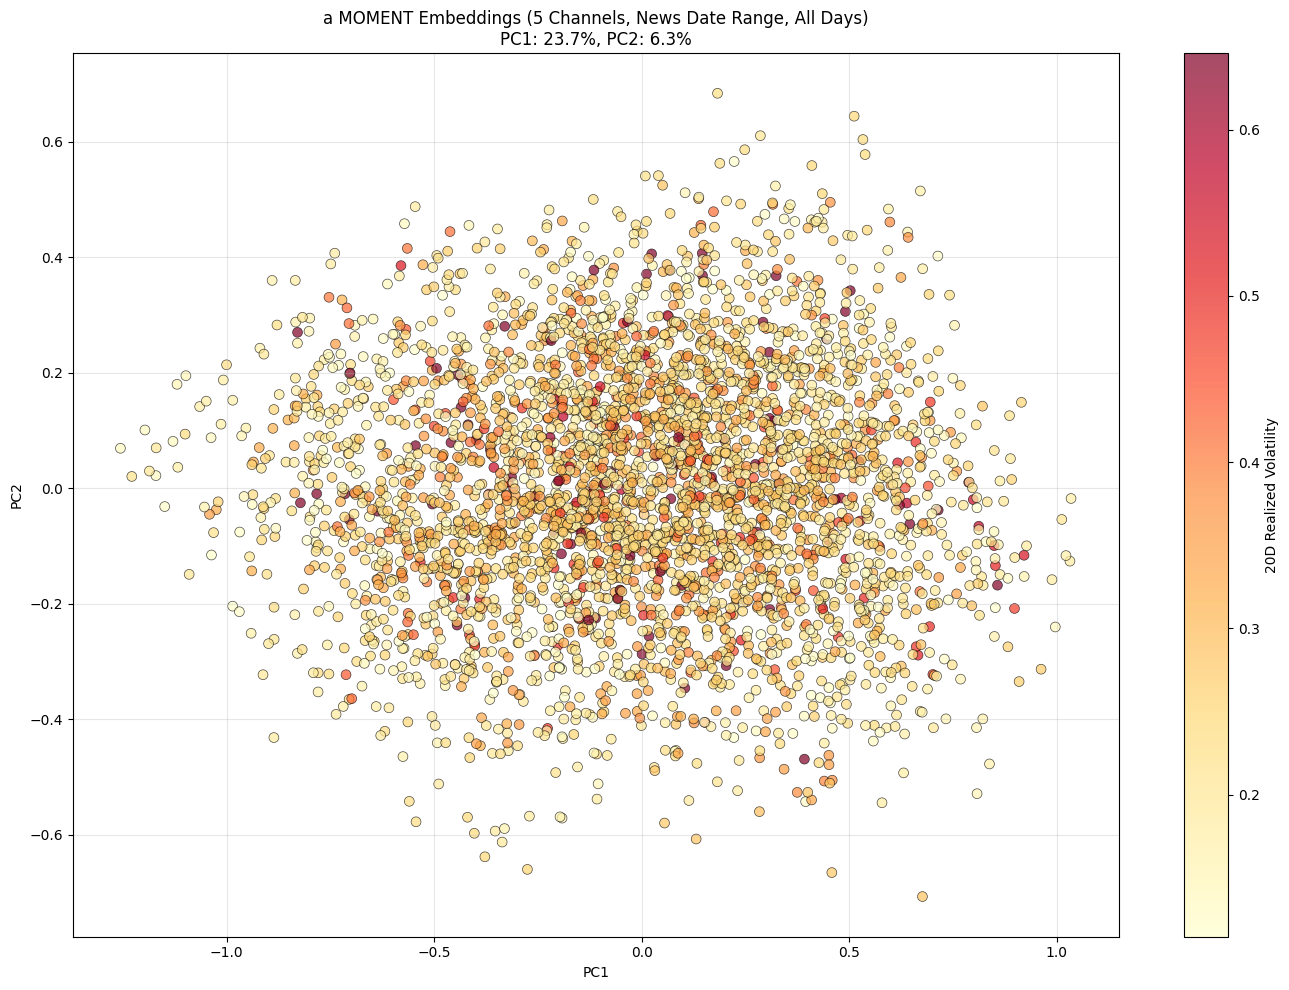


Date coverage: 2010-04-15 00:00:00 → 2025-03-28 00:00:00
Total embeddings: 3763
Channels: ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']
Max sequence length: 23

Sample data:
        date   vol_20d  n_days
0 2010-04-15  0.170110      22
1 2010-04-16  0.175407      22
2 2010-04-19  0.183511      20
3 2010-04-20  0.205819      21
4 2010-04-21  0.202713      22
5 2010-04-22  0.201519      22
6 2010-04-23  0.198883      22
7 2010-04-26  0.197752      20
8 2010-04-27  0.204798      21
9 2010-04-28  0.202140      22


In [26]:
first_ticker = list(ticker_to_df.keys())[0]
print(f"Generating MOMENT embeddings: {first_ticker}")
print(f"Processing dates matching news data (5 channels, 30-day context)\n")

ticker_data = ticker_to_df[first_ticker].copy().sort_values("Date")
ticker_data["Date"] = pd.to_datetime(ticker_data["Date"]).dt.normalize()

X_data = ticker_to_X[first_ticker]
selected_channels = ['Close', 'rsi_14', 'atr_14', 'bb_bandwidth', 'adx']
channel_indices = [X_data.columns.get_loc(ch) for ch in selected_channels]

news_date_min = cluster_df["date"].min()
news_date_max = cluster_df["date"].max()
print(f"News date range: {news_date_min} to {news_date_max}")

window_days = 30
batch_size_moment = 32

moment_embeddings_first = []
moment_metadata_first = []
multi_channel_first = []

ticker_data_filtered = ticker_data[(ticker_data["Date"] >= news_date_min) & (ticker_data["Date"] <= news_date_max)].copy()
print(f"Ticker data filtered: {len(ticker_data)} → {len(ticker_data_filtered)} days")
print(f"Selected channels (5): {selected_channels}\n")

for idx, date in enumerate(ticker_data_filtered['Date'].values):
    if idx % 500 == 0:
        print(f"Processing date {idx}/{len(ticker_data_filtered)}...")
    
    date = pd.Timestamp(date)
    window_start = date - pd.Timedelta(days=window_days)
    window_data = ticker_data[(ticker_data["Date"] >= window_start) & (ticker_data["Date"] <= date)].copy()
    
    if len(window_data) < 5:
        continue
    
    feature_window_all = X_data.loc[window_data.index].values.astype(np.float32)
    feature_window = feature_window_all[:, channel_indices]
    close = window_data["Close"].astype(float).values
    
    if len(feature_window) < 5:
        continue
    
    log_ret = np.diff(np.log(close)).astype(np.float32)
    vol_20d_calc = np.std(log_ret) * np.sqrt(252)
    
    multi_channel_first.append(feature_window)
    moment_metadata_first.append({
        "ticker": first_ticker.upper(),
        "date": date,
        "vol_20d": vol_20d_calc,
        "n_days": len(window_data)
    })

print(f"\nPrepared {len(multi_channel_first)} windows")

if len(multi_channel_first) > 0:
    max_seq_len = max(x.shape[0] for x in multi_channel_first)
    n_channels = multi_channel_first[0].shape[1]
    print(f"Max sequence length: {max_seq_len}, Channels: {n_channels}")
    
    multi_channel_padded = []
    for x in multi_channel_first:
        if x.shape[0] < max_seq_len:
            pad_len = max_seq_len - x.shape[0]
            x_padded = np.pad(x, ((0, pad_len), (0, 0)), mode='edge').astype(np.float32)
        else:
            x_padded = x
        multi_channel_padded.append(x_padded)
    
    print(f"Padded {len(multi_channel_padded)} windows\n")
    
    moment_embeddings_first = []
    print(f"Generating embeddings (batch_size={batch_size_moment})...")
    
    with torch.no_grad():
        for i in range(0, len(multi_channel_padded), batch_size_moment):
            if i % (batch_size_moment * 10) == 0:
                print(f"  Processing [{i}/{len(multi_channel_padded)}]...")
            
            batch_list = multi_channel_padded[i:i+batch_size_moment]
            batch = torch.from_numpy(np.array(batch_list, dtype=np.float32)).transpose(1, 2)
            
            try:
                outputs = model(x_enc=batch)
                moment_embeddings_first.append(outputs.embeddings.cpu().numpy())
            except Exception as e:
                print(f"  Error at batch {i}: {str(e)[:50]}")
                continue
    
    if moment_embeddings_first:
        emb_np = np.vstack(moment_embeddings_first)
        print(f"\n✓ Generated {emb_np.shape[0]} embeddings, dim={emb_np.shape[1]}")
        
        pca_2d = PCA(n_components=2, random_state=42).fit_transform(emb_np)
        pca_var = PCA(n_components=2, random_state=42).fit(emb_np).explained_variance_ratio_
        
        meta_df = pd.DataFrame(moment_metadata_first)
        meta_df["x"] = pca_2d[:, 0]
        meta_df["y"] = pca_2d[:, 1]
        
        fig, ax = plt.subplots(figsize=(14, 10))
        vol_df = meta_df.dropna(subset=["vol_20d"]).copy()
        
        if not vol_df.empty:
            q_low, q_high = vol_df["vol_20d"].quantile([0.02, 0.98]).tolist()
            vol_clip = vol_df["vol_20d"].clip(q_low, q_high)
            sc = ax.scatter(vol_df["x"], vol_df["y"], c=vol_clip, cmap="YlOrRd", 
                          alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
            plt.colorbar(sc, ax=ax, label="20D Realized Volatility")
        
        ax.set_title(f"{first_ticker} MOMENT Embeddings (5 Channels, News Date Range, All Days)\nPC1: {pca_var[0]:.1%}, PC2: {pca_var[1]:.1%}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.savefig(f'images/moment_{first_ticker}_5ch_all_news_dates.png', dpi=150, bbox_inches='tight')
        print(f"Saved: images/moment_{first_ticker}_5ch_all_news_dates.png")
        plt.show()
        
        print(f"\nDate coverage: {meta_df['date'].min()} → {meta_df['date'].max()}")
        print(f"Total embeddings: {len(meta_df)}")
        print(f"Channels: {selected_channels}")
        print(f"Max sequence length: {max_seq_len}")
        print(f"\nSample data:")
        print(meta_df[["date", "vol_20d", "n_days"]].head(10))
    else:
        print("No embeddings generated")
else:
    print("No windows prepared")


# Multimodal Fusion: FiLM vs Gating

## Option A: FiLM (Feature-wise Linear Modulation)

Feature-wise Linear Modulation modulates the numerical embeddings using parameters derived from text:

$$h = \text{MLP}(x_t^{\text{numerical}})$$

$$\gamma, \beta = g(z_t^{\text{text}})$$

$$x_{\text{modulated}} = \gamma \odot h + \beta$$

**Interpretation:** Text embedding acts as a "soft conditioning signal" that learns *what features to amplify* (γ) and *what baseline to set* (β) for the numerical representation.

**Advantages:**
- Computationally cheap (one MLP, two linear projections)
- Powerful: adaptive feature scaling and shifting
- Interpretable: γ shows feature importance, β shows baseline shift
- Non-destructive: learned modulation, not hard gating

---

## Option B: Gating (Production-Grade Fusion)

Gating learns a soft binary mask for trust/confidence:

$$\text{gate} = \sigma(W z_t^{\text{text}})$$

$$x_{\text{fused}} = \text{gate} \odot x_t^{\text{numerical}}$$

where σ is sigmoid (output ∈ [0,1]).

**Interpretation:** "How much should I trust the numerical signal at time t based on the text context?" 
- gate ≈ 1: high confidence in numerical signal
- gate ≈ 0: suppress numerical signal (high text uncertainty)

**Advantages:**
- Simple, interpretable binary reasoning
- Robust to noisy text embeddings
- Production-grade: widely used in recommendation systems
- Single parameter vector: W ∈ ℝ^{d_text → 1}

Device: cpu

✓ Numerical embeddings: torch.Size([3763, 1024])
✓ Text embeddings (aligned): torch.Size([3763, 384])

✓ FiLM fused embeddings: (3763, 1024)
✓ Gating fused embeddings: (3763, 1024)

✓ Saved: images/fusion_comparison_film_vs_gating.png

FiLM variance explained: 46.6%
Gating variance explained: 30.1%


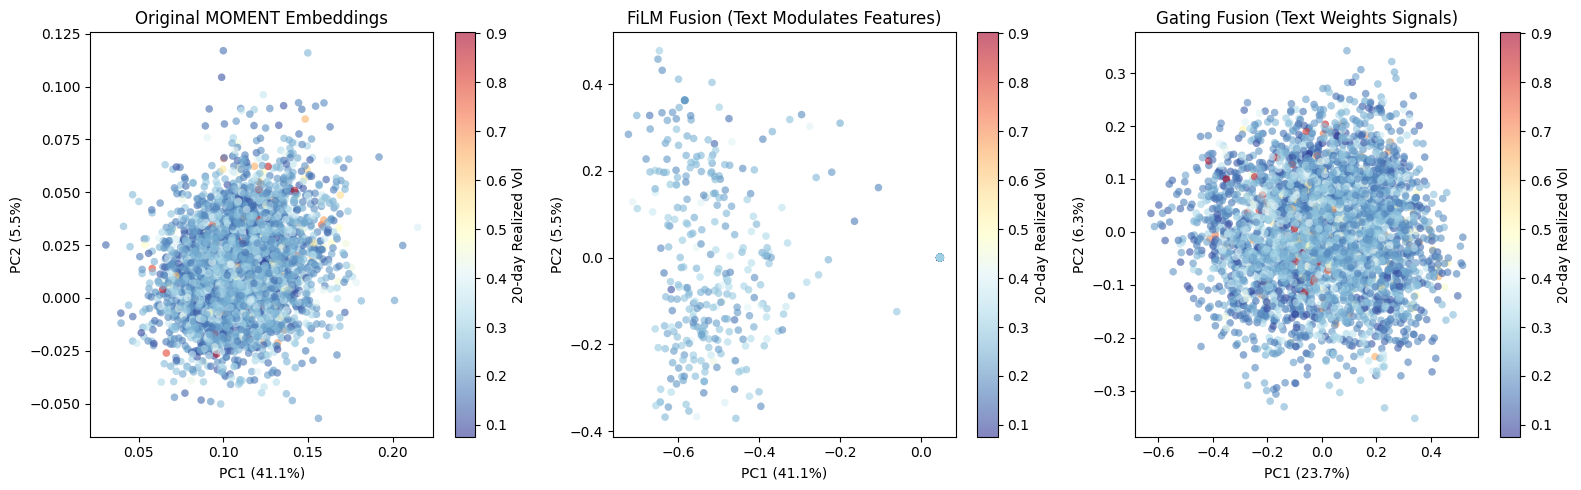

In [28]:
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

class FiLMFusion(nn.Module):
    def __init__(self, d_numerical, d_text, hidden_dim=256):
        super().__init__()
        self.mlp_numerical = nn.Sequential(
            nn.Linear(d_numerical, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d_numerical)
        )
        self.gamma_proj = nn.Linear(d_text, d_numerical)
        self.beta_proj = nn.Linear(d_text, d_numerical)
    
    def forward(self, x_numerical, z_text):
        h = self.mlp_numerical(x_numerical)
        gamma = self.gamma_proj(z_text)
        beta = self.beta_proj(z_text)
        return gamma * h + beta


class GatingFusion(nn.Module):
    def __init__(self, d_text, d_numerical):
        super().__init__()
        self.gate_proj = nn.Linear(d_text, d_numerical)
    
    def forward(self, x_numerical, z_text):
        gate = torch.sigmoid(self.gate_proj(z_text))
        return gate * x_numerical


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

x_numerical_torch = torch.from_numpy(emb_np).float().to(device)

all_dates_range = pd.date_range(cluster_df['date'].min(), cluster_df['date'].max(), freq='D')
meta_dates = pd.to_datetime(meta_df['date'].values)
indices_in_full = [np.where(all_dates_range == d)[0][0] for d in meta_dates if d in all_dates_range]

z_text_subset = z_context_full[indices_in_full]
z_text_torch = torch.from_numpy(z_text_subset).float().to(device)

print(f"\n✓ Numerical embeddings: {x_numerical_torch.shape}")
print(f"✓ Text embeddings (aligned): {z_text_torch.shape}")

d_numerical = emb_np.shape[1]
d_text = z_text_subset.shape[1]

film_model = FiLMFusion(d_numerical, d_text).to(device)
gating_model = GatingFusion(d_text, d_numerical).to(device)

with torch.no_grad():
    z_film = film_model(x_numerical_torch, z_text_torch).cpu().numpy()
    z_gating = gating_model(x_numerical_torch, z_text_torch).cpu().numpy()

print(f"\n✓ FiLM fused embeddings: {z_film.shape}")
print(f"✓ Gating fused embeddings: {z_gating.shape}")

pca = PCA(n_components=2)
pca_film = pca.fit_transform(z_film)
pca_gating = PCA(n_components=2).fit_transform(z_gating)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vol_colors = meta_df['vol_20d'].values
cmap = plt.cm.RdYlBu_r

ax = axes[0]
sc = ax.scatter(pca.transform(emb_np)[:, 0], pca.transform(emb_np)[:, 1], 
                c=vol_colors, cmap=cmap, alpha=0.6, s=30, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Original MOMENT Embeddings')
plt.colorbar(sc, ax=ax, label='20-day Realized Vol')

ax = axes[1]
pca_film_obj = PCA(n_components=2)
pca_film_2d = pca_film_obj.fit_transform(z_film)
sc = ax.scatter(pca_film_2d[:, 0], pca_film_2d[:, 1], 
                c=vol_colors, cmap=cmap, alpha=0.6, s=30, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_film_obj.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_film_obj.explained_variance_ratio_[1]:.1%})')
ax.set_title('FiLM Fusion (Text Modulates Features)')
plt.colorbar(sc, ax=ax, label='20-day Realized Vol')

ax = axes[2]
pca_gating_obj = PCA(n_components=2)
pca_gating_2d = pca_gating_obj.fit_transform(z_gating)
sc = ax.scatter(pca_gating_2d[:, 0], pca_gating_2d[:, 1], 
                c=vol_colors, cmap=cmap, alpha=0.6, s=30, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_gating_obj.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_gating_obj.explained_variance_ratio_[1]:.1%})')
ax.set_title('Gating Fusion (Text Weights Signals)')
plt.colorbar(sc, ax=ax, label='20-day Realized Vol')

plt.tight_layout()
plt.savefig('images/fusion_comparison_film_vs_gating.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: images/fusion_comparison_film_vs_gating.png")

print(f"\nFiLM variance explained: {pca_film_obj.explained_variance_ratio_.sum():.1%}")
print(f"Gating variance explained: {pca_gating_obj.explained_variance_ratio_.sum():.1%}")

# Volatility Prediction using Multimodal Embeddings

Train predictive models on MOMENT, FiLM, and Gating embeddings to forecast 20-day realized volatility.

VOLATILITY PREDICTION WITH MULTIMODAL EMBEDDINGS

MOMENT (Baseline)
------------------------------------------------------------
  Train R²:    0.2300
  Test R²:     0.0174
  Test MAE:    0.0775
  Test RMSE:   0.1124

FiLM Fusion
------------------------------------------------------------
  Train R²:    0.0079
  Test R²:    -0.0034
  Test MAE:    0.0779
  Test RMSE:   0.1135

Gating Fusion
------------------------------------------------------------
  Train R²:    0.1238
  Test R²:     0.0342
  Test MAE:    0.0760
  Test RMSE:   0.1114


✓ Saved: images/volatility_predictions_comparison.png

🏆 Best model: Gating Fusion (R² = 0.0342)
✓ Saved: images/volatility_timeseries_prediction.png


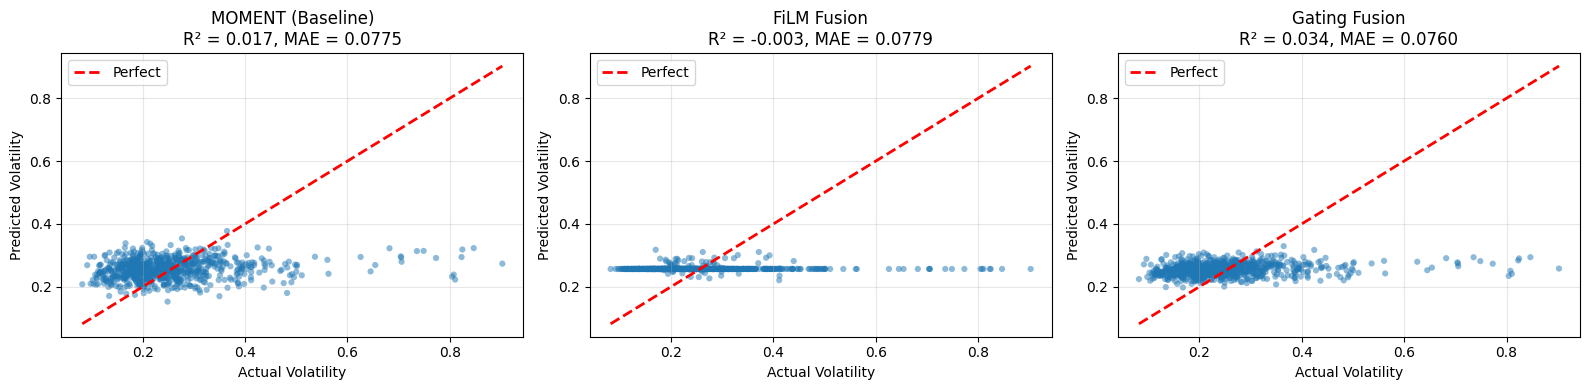

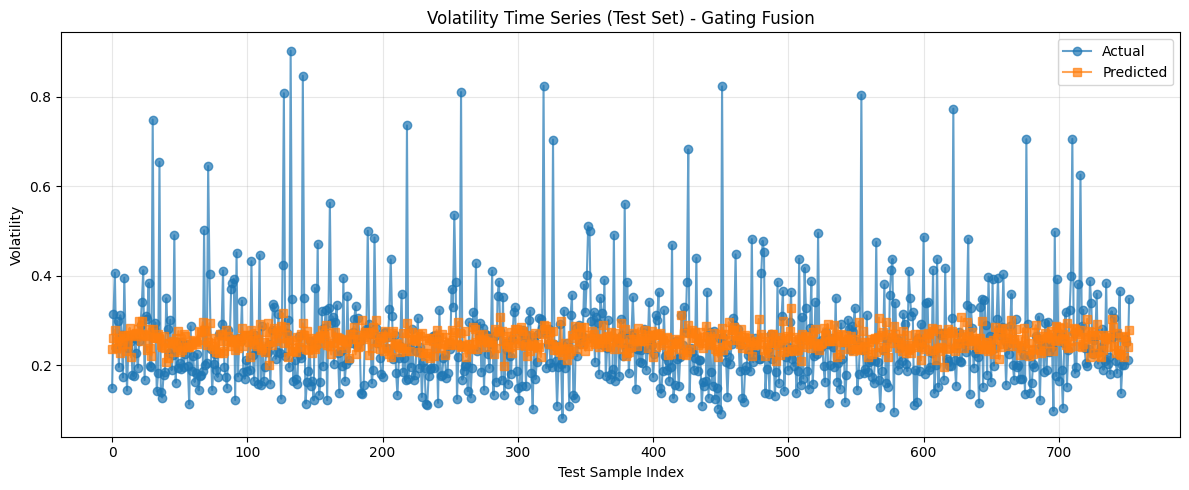

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

y_true = meta_df['vol_20d'].values

X_train, X_test, y_train, y_test = train_test_split(
    emb_np, y_true, test_size=0.2, random_state=42
)

print("=" * 60)
print("VOLATILITY PREDICTION WITH MULTIMODAL EMBEDDINGS")
print("=" * 60)

results = {}

for name, X_full in [
    ("MOMENT (Baseline)", emb_np),
    ("FiLM Fusion", z_film),
    ("Gating Fusion", z_gating)
]:
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_true, test_size=0.2, random_state=42
    )
    
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'model': model,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'y_train': y_train,
        'y_test': y_test,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    }
    
    print(f"\n{name}")
    print("-" * 60)
    print(f"  Train R²:  {r2_score(y_train, y_pred_train):>8.4f}")
    print(f"  Test R²:   {r2:>8.4f}")
    print(f"  Test MAE:  {mae:>8.4f}")
    print(f"  Test RMSE: {rmse:>8.4f}")

print("\n" + "=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for (name, res), ax in zip(results.items(), axes):
    ax.scatter(res['y_test'], res['y_pred_test'], alpha=0.5, s=20, edgecolors='none')
    
    min_val = min(res['y_test'].min(), res['y_pred_test'].min())
    max_val = max(res['y_test'].max(), res['y_pred_test'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
    
    ax.set_xlabel('Actual Volatility')
    ax.set_ylabel('Predicted Volatility')
    ax.set_title(f"{name}\nR² = {res['r2']:.3f}, MAE = {res['mae']:.4f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/volatility_predictions_comparison.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: images/volatility_predictions_comparison.png")

best_model_name = max(results, key=lambda k: results[k]['r2'])
print(f"\n🏆 Best model: {best_model_name} (R² = {results[best_model_name]['r2']:.4f})")

fig, ax = plt.subplots(figsize=(12, 5))
times = np.arange(len(results[best_model_name]['y_test']))
ax.plot(times, results[best_model_name]['y_test'], 'o-', label='Actual', alpha=0.7, linewidth=1.5)
ax.plot(times, results[best_model_name]['y_pred_test'], 's-', label='Predicted', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Volatility')
ax.set_title(f'Volatility Time Series (Test Set) - {best_model_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/volatility_timeseries_prediction.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: images/volatility_timeseries_prediction.png")